# Revision Plotting — Paper Figure Redraw

Redraws all 9 paper figures at high resolution with updated terminology
(old **deception** class → **Falsehood compliance**), per `figure_redraw_spec.md`.

**Conventions**
- Class relabel: `deception` → `Falsehood compliance` (legends, panel titles, axes).
- Steering vectors: `v_deception` → `v_fc`, `v_dec_vs_mistake` → `v_fc_vs_mistake` (`v_mistake` unchanged).
- Layout kept identical to the original `pics.ipynb` / `summary.ipynb` figures.
- Every figure exported as **vector PDF + 300 DPI PNG** to `summary/figures_revision/`.

**Data sources**
- Probe-performance figures: `summary/*.csv` (per-config probe results).
- Flip-rate figure: `steering_results/correctness_summary.csv`, column `flip_rate`
  (debate-prompt vectors; *not* `pct_changed`, which is text-change rate).


In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path

DPI = 300
matplotlib.rcParams.update({
    "figure.dpi":        DPI,
    "savefig.dpi":       DPI,
    "pdf.fonttype":      42,   # embed TrueType (selectable text in vector PDF)
    "ps.fonttype":       42,
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
    "lines.linewidth":   1.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

SUMMARY_DIR = Path("summary")
STEER_CSV   = Path("steering_results/correctness_summary.csv")
FIG_DIR     = SUMMARY_DIR / "figures_revision"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Four probe architectures (color = probe, fixed across all probe-performance figures)
PROBES = [
    ("3way_lr",      "3-Way LR",     "#2166AC"),
    ("3way_mlp",     "3-Way MLP",    "#E08214"),
    ("cascaded_lr",  "Cascaded LR",  "#1A9641"),
    ("cascaded_mlp", "Cascaded MLP", "#D73027"),
]

# Per-metric panels.  NOTE relabel: deception -> Falsehood compliance.
METRICS = [
    ("f1_macro",          "Macro F1"),
    ("f1_truth",          "F1: Truth"),
    ("f1_deception",      "F1: Falsehood compliance"),
    ("f1_honest_mistake", "F1: Honest mistake"),
]


def export(fig, name):
    """Save a figure as both vector PDF and 300-DPI PNG, then display inline."""
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=DPI, bbox_inches="tight")
    print("Saved:", FIG_DIR / f"{name}.[pdf|png]")
    plt.show()

print("Setup complete. Figures will be saved to:", FIG_DIR.resolve())

Setup complete. Figures will be saved to: D:\code\kmsa_2026spring_Algoverse\summary\figures_revision


## Figure 1 — Qwen2.5-7B probe performance (concise vs debate)

Saved: summary\figures_revision\fig1_qwen25_probe_performance.[pdf|png]


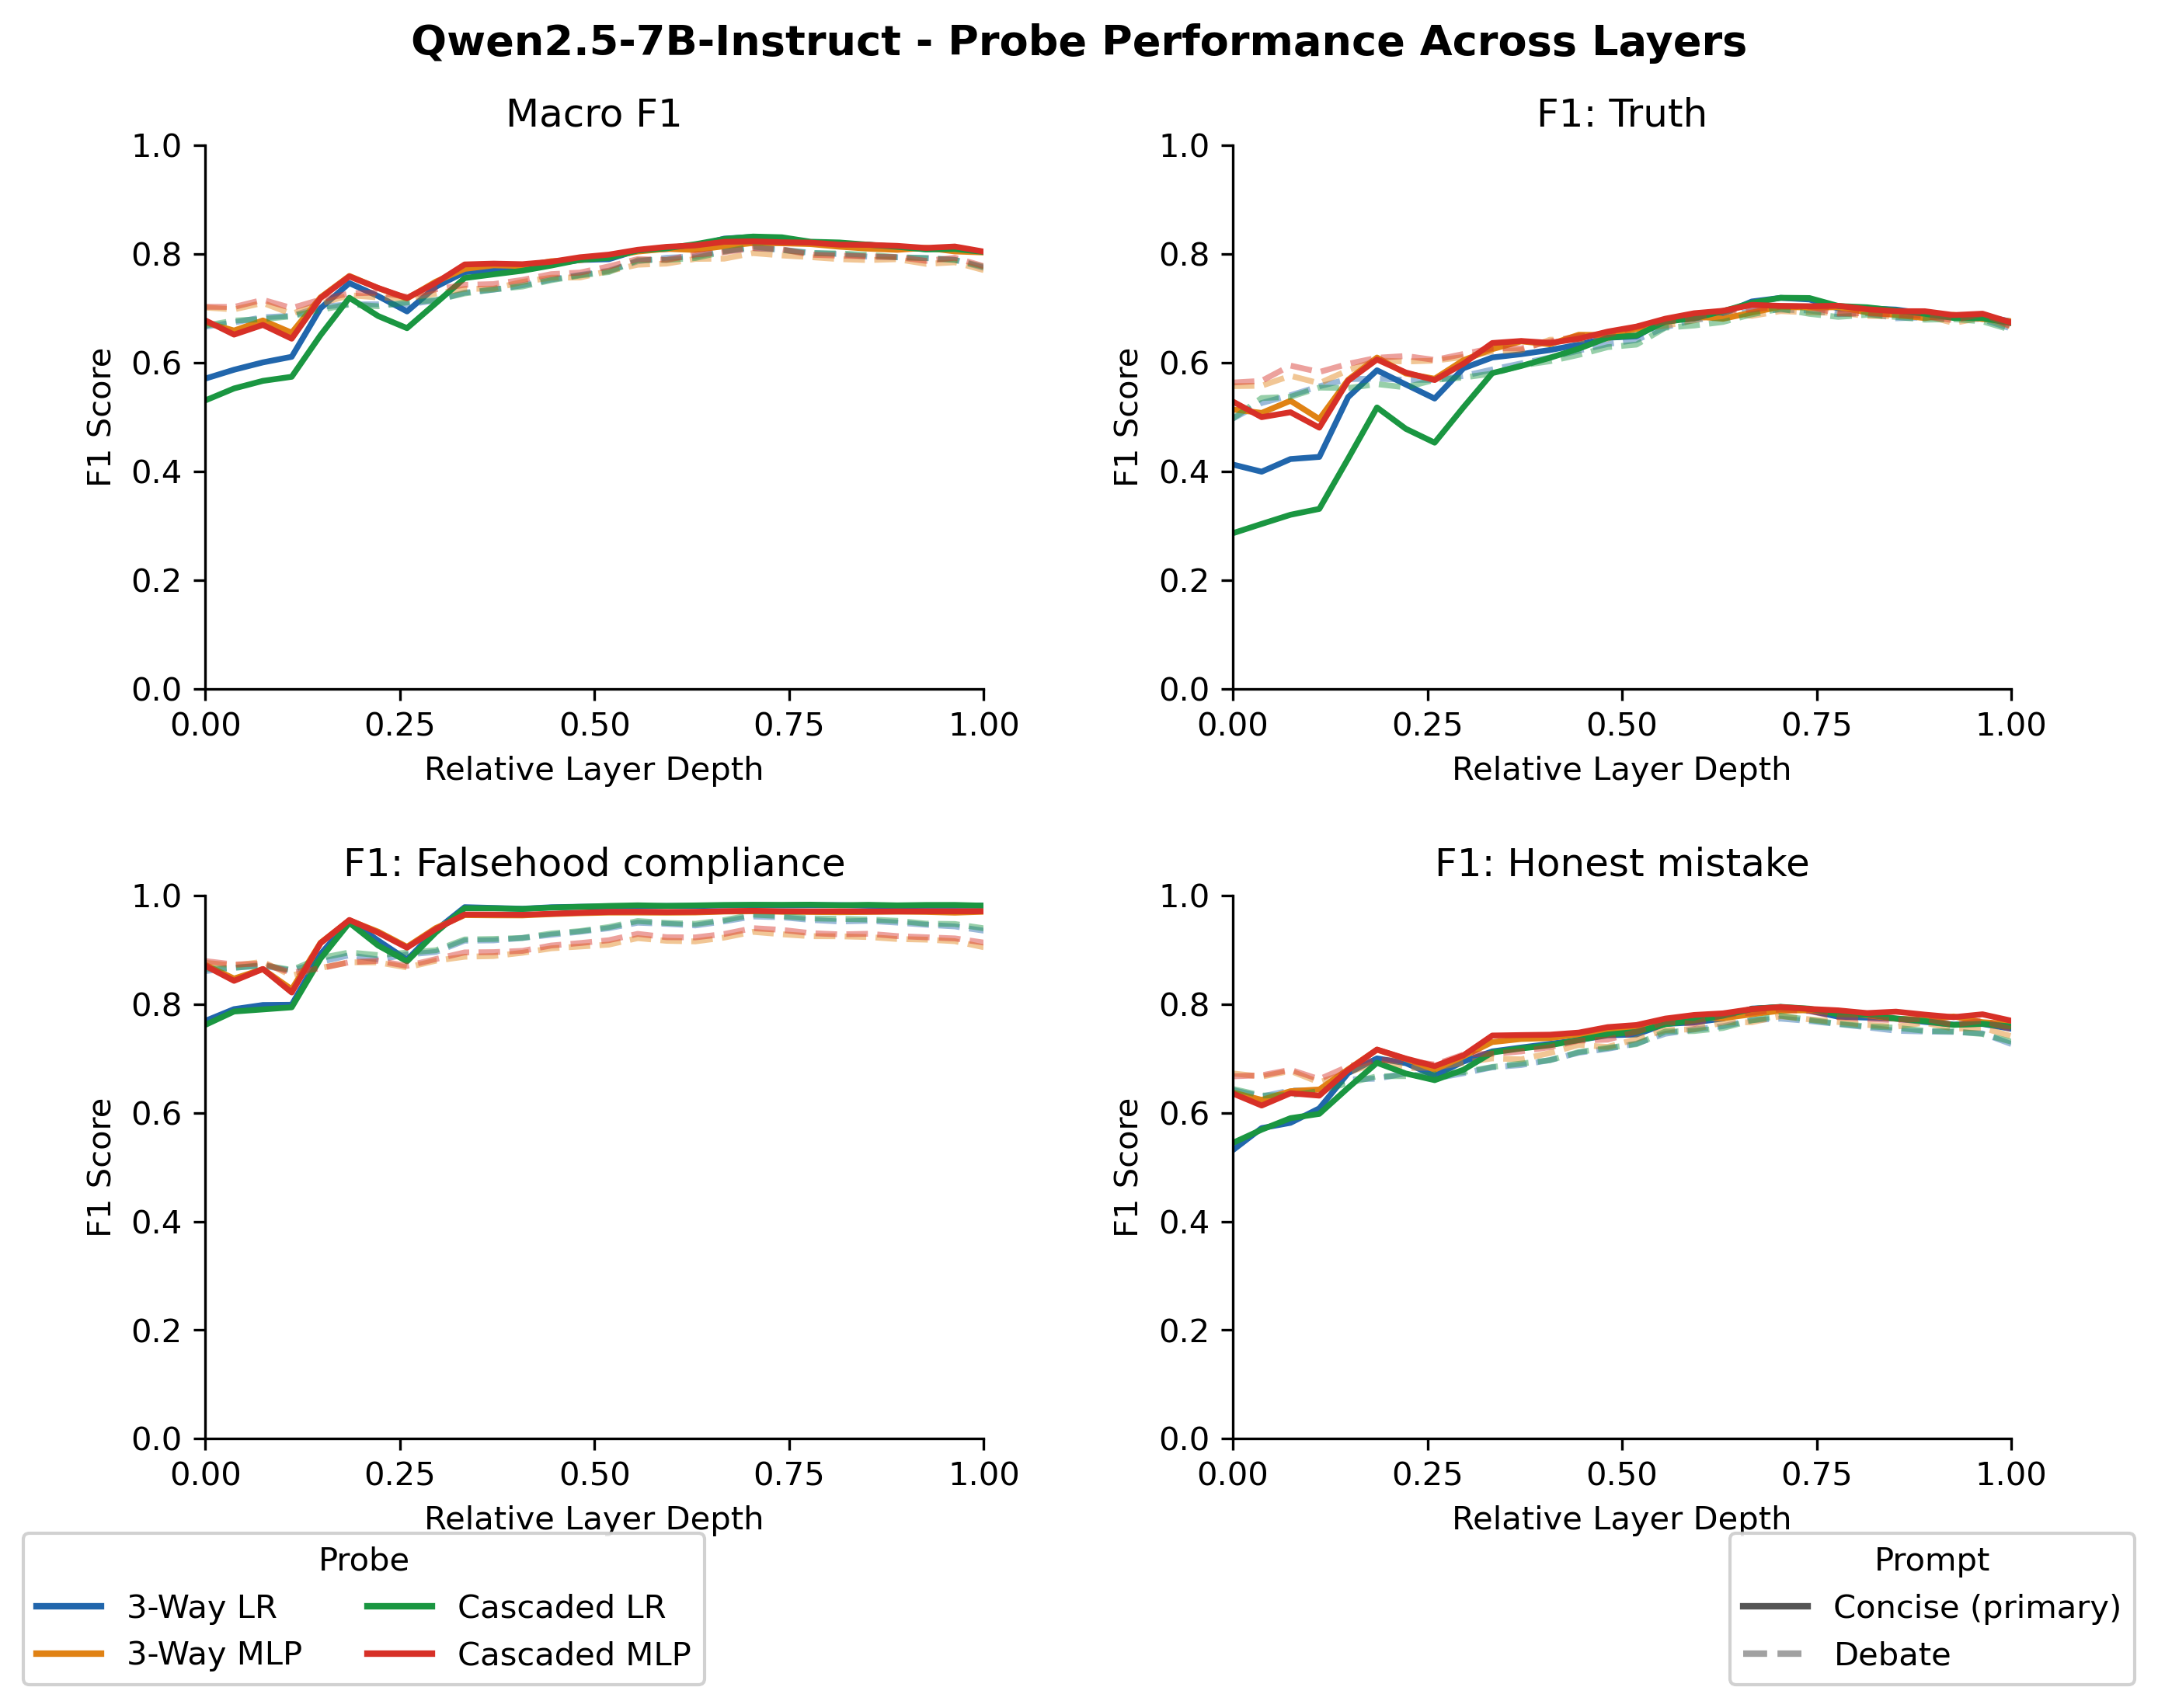

In [2]:
def _load_q25(probe_key, prompt):
    df = pd.read_csv(SUMMARY_DIR / f"qwen2.5_{probe_key}_{prompt}.csv")
    df["rel_layer"] = df["layer"] / (len(df) - 1)
    return df

fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
fig.subplots_adjust(hspace=0.38, wspace=0.32, bottom=0.16, top=0.90)
for ax, (col, title) in zip(axes.flat, METRICS):
    for probe_key, _, color in PROBES:
        df_c = _load_q25(probe_key, "concise")
        df_d = _load_q25(probe_key, "debate")
        ax.plot(df_c["rel_layer"], df_c[col], color=color, ls="-",  alpha=1.0,  lw=1.8)
        ax.plot(df_d["rel_layer"], df_d[col], color=color, ls="--", alpha=0.45, lw=1.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Relative Layer Depth", fontsize=10)
    ax.set_ylabel("F1 Score", fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))
fig.suptitle("Qwen2.5-7B-Instruct - Probe Performance Across Layers",
             fontsize=13, fontweight="bold", y=0.97)
probe_handles = [Line2D([0], [0], color=c, lw=2, ls="-", label=lbl) for _, lbl, c in PROBES]
style_handles = [
    Line2D([0], [0], color="#555555", lw=2, ls="-",  label="Concise (primary)"),
    Line2D([0], [0], color="#555555", lw=2, ls="--", alpha=0.55, label="Debate"),
]
fig.legend(handles=probe_handles, title="Probe", title_fontsize=10,
           ncols=2, loc="lower left", bbox_to_anchor=(0.04, 0.01), framealpha=0.9)
fig.legend(handles=style_handles, title="Prompt", title_fontsize=10,
           ncols=1, loc="lower right", bbox_to_anchor=(0.96, 0.01), framealpha=0.9)
export(fig, "fig1_qwen25_probe_performance")

## Figure 2 — Flip rate vs steering strength α

Debate-prompt CAA vectors, layers 14–22. Line = mean across layers; shaded band = min–max.
`v_fc` reaches ~84–94% at α=5; `v_mistake` stays ≤30%; `v_fc_vs_mistake` tracks `v_fc`.

Saved: summary\figures_revision\fig_flip_rate_vs_alpha.[pdf|png]


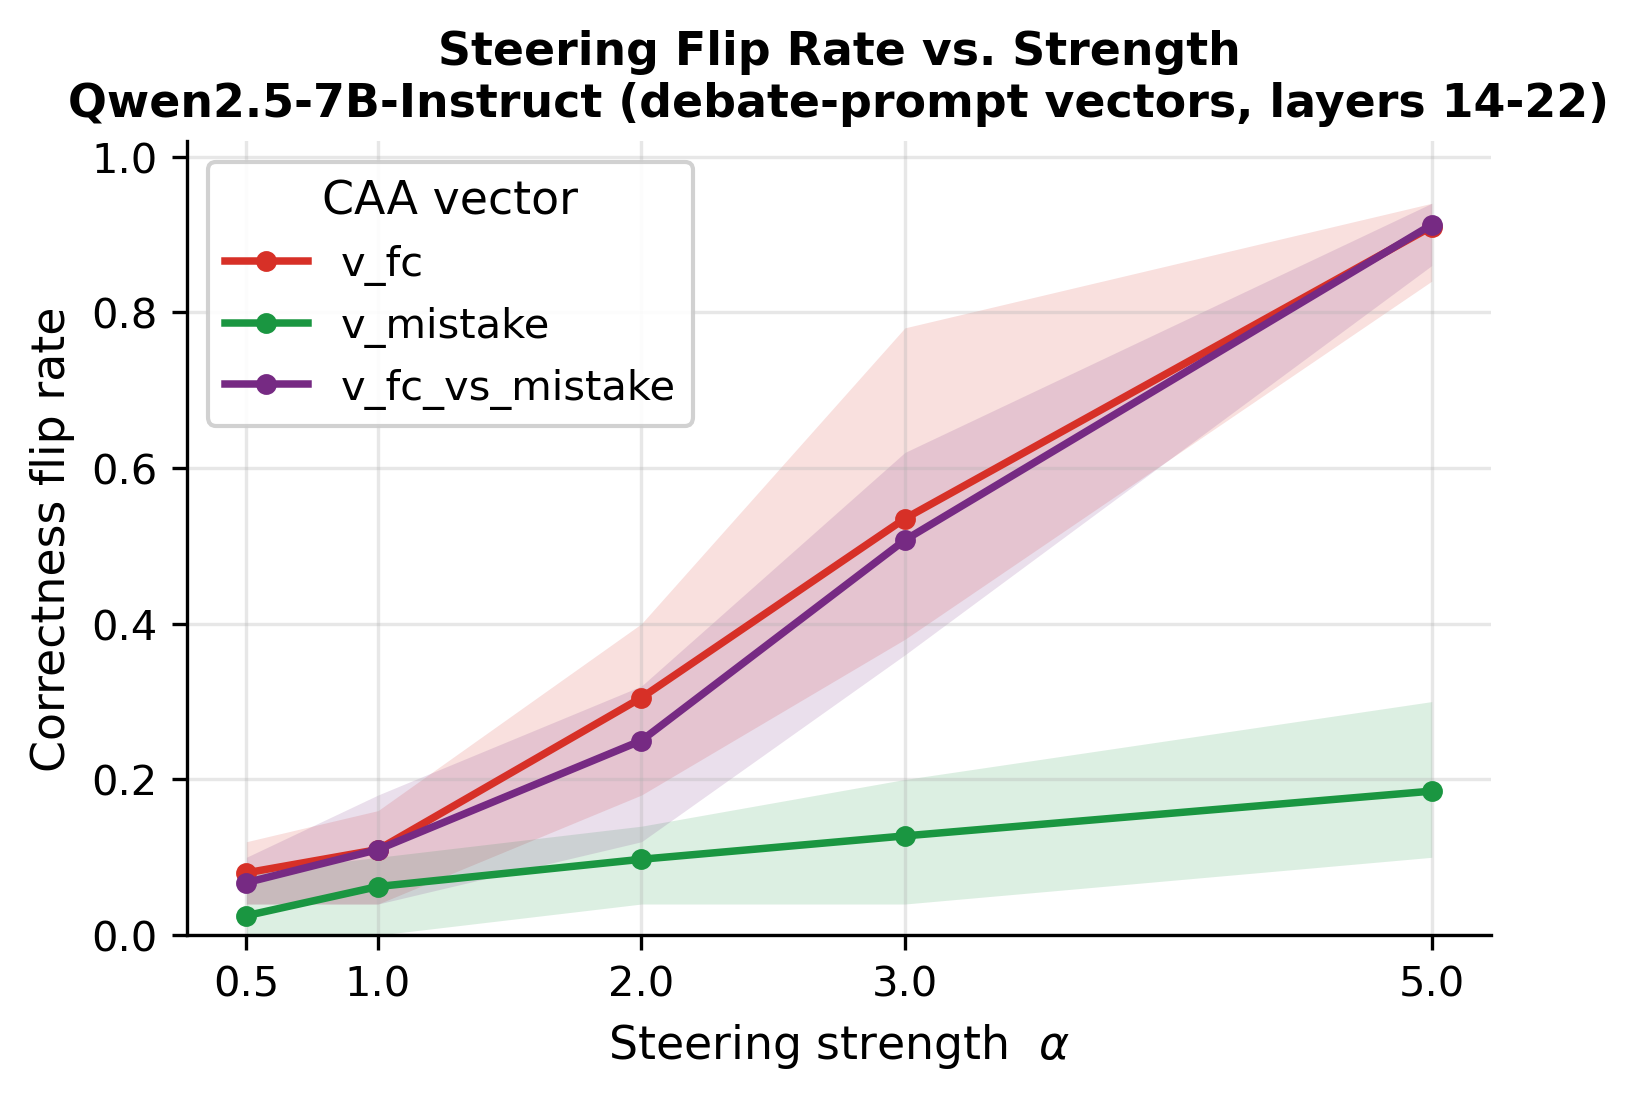

In [3]:
steer = pd.read_csv(STEER_CSV)

# vector_type -> (display name, color).  v_fc = falsehood-compliance direction.
VECTORS = [
    ("v_deception",      "v_fc",            "#D73027"),  # red
    ("v_mistake",        "v_mistake",       "#1A9641"),  # green
    ("v_dec_vs_mistake", "v_fc_vs_mistake", "#762A83"),  # purple
]
ALPHAS = sorted(steer["alpha"].unique())

fig, ax = plt.subplots(figsize=(5.2, 3.8))
for vt, disp, color in VECTORS:
    g = (steer[steer["vector_type"] == vt]
         .groupby("alpha")["flip_rate"]
         .agg(["mean", "min", "max"])
         .reindex(ALPHAS))
    ax.plot(ALPHAS, g["mean"], color=color, marker="o", markersize=4, lw=1.8, label=disp)
    ax.fill_between(ALPHAS, g["min"], g["max"], color=color, alpha=0.15, linewidth=0)
ax.set_xlabel("Steering strength  " + r"$\alpha$", fontsize=11)
ax.set_ylabel("Correctness flip rate", fontsize=11)
ax.set_title("Steering Flip Rate vs. Strength\nQwen2.5-7B-Instruct (debate-prompt vectors, layers 14-22)",
             fontsize=11, fontweight="bold")
ax.set_xticks(ALPHAS)
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(title="CAA vector", framealpha=0.9, loc="upper left")
fig.tight_layout()
export(fig, "fig_flip_rate_vs_alpha")

## Figure 3 (appendix) — `pair_a_perclass_f1`

Robustness to falsehood-inducing prompt format: per-class F1 (rows) × probe (cols),
Qwen2.5 concise vs debate.

Saved: summary\figures_revision\pair_a_perclass_f1.[pdf|png]


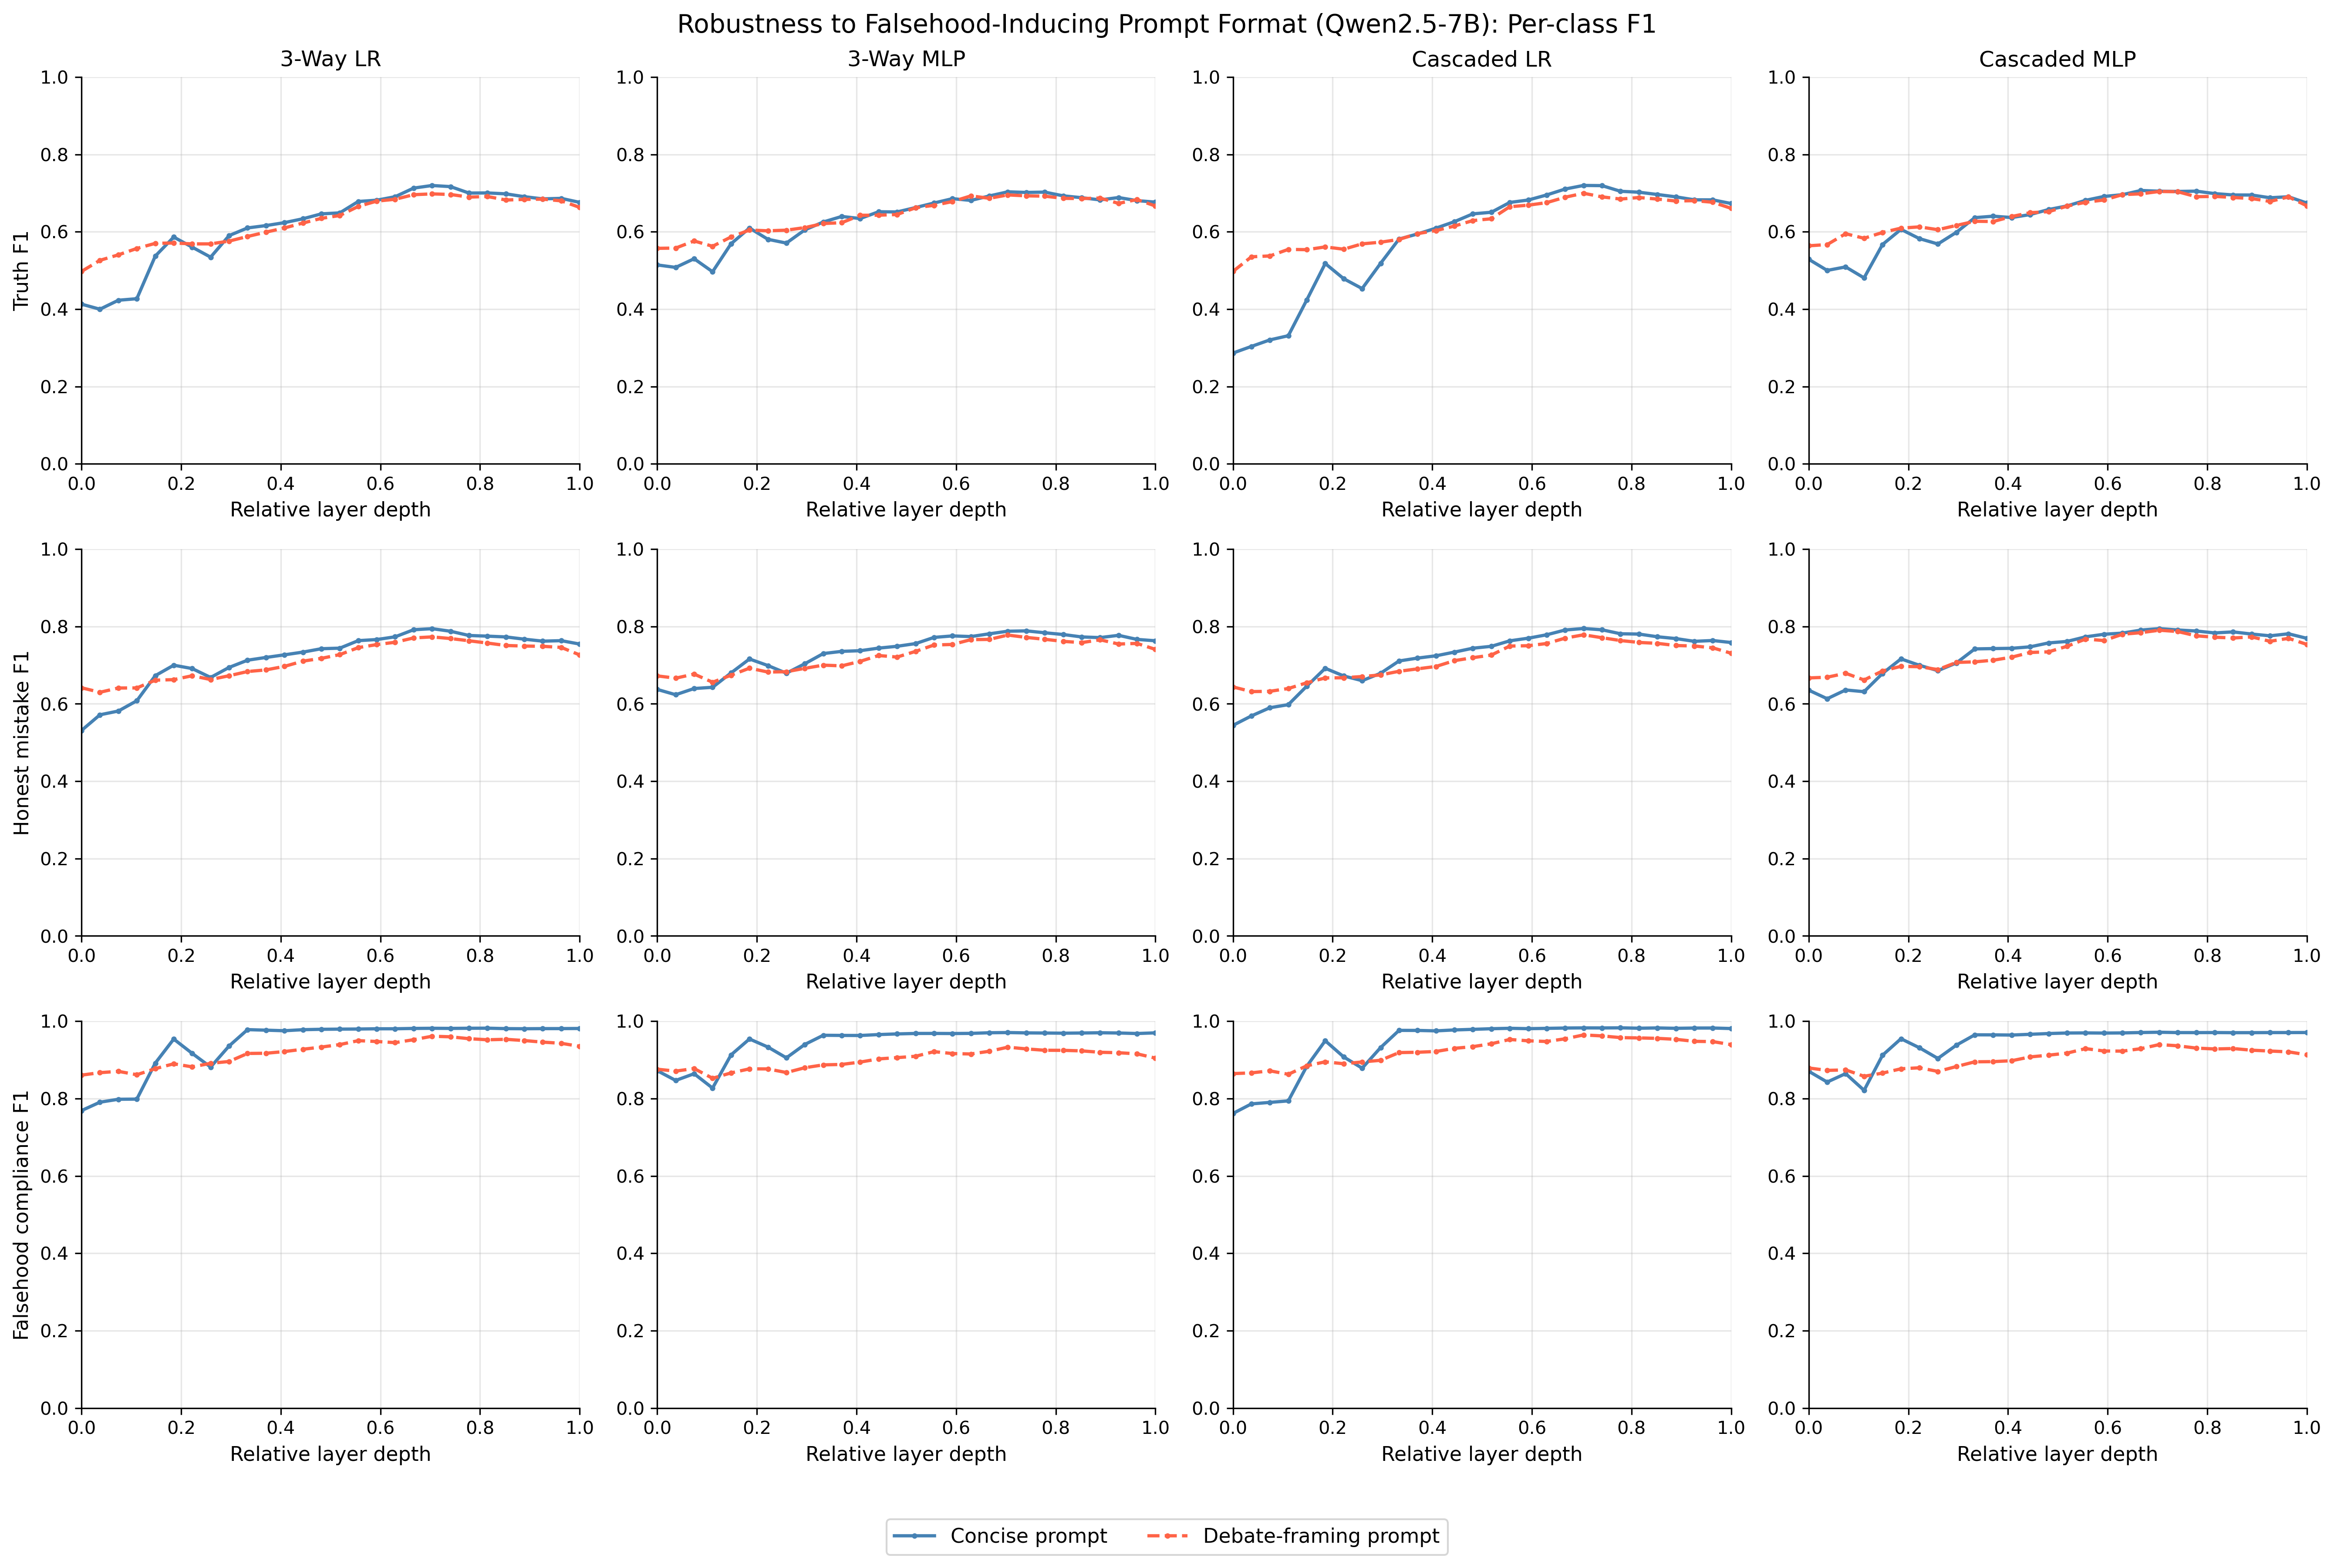

In [4]:
PROBE_TYPES = [
    ("3way_lr",      "3-Way LR"),
    ("3way_mlp",     "3-Way MLP"),
    ("cascaded_lr",  "Cascaded LR"),
    ("cascaded_mlp", "Cascaded MLP"),
]
PER_CLASS_ROWS = [
    ("f1_truth",          "Truth"),
    ("f1_honest_mistake", "Honest mistake"),
    ("f1_deception",      "Falsehood compliance"),
]
PAIR_A = [
    ("concise", "Concise prompt",        "steelblue", "-"),
    ("debate",  "Debate-framing prompt", "tomato",    "--"),
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for col_i, (probe_key, ptitle) in enumerate(PROBE_TYPES):
    for row_i, (fcol, flabel) in enumerate(PER_CLASS_ROWS):
        ax = axes[row_i, col_i]
        for prompt, label, color, ls in PAIR_A:
            df = pd.read_csv(SUMMARY_DIR / f"qwen2.5_{probe_key}_{prompt}.csv")
            df["rel_layer"] = df["layer"] / (len(df) - 1)
            ax.plot(df["rel_layer"], df[fcol], label=label, color=color,
                    linestyle=ls, marker="o", markersize=2)
        if row_i == 0:
            ax.set_title(ptitle)
        if col_i == 0:
            ax.set_ylabel(f"{flabel} F1")
        ax.set_xlabel("Relative layer depth")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Robustness to Falsehood-Inducing Prompt Format (Qwen2.5-7B): Per-class F1", fontsize=14)
fig.tight_layout(rect=[0, 0.04, 1, 1])
export(fig, "pair_a_perclass_f1")

## Figures 4 & 5 (appendix) — thinking vs non-thinking (Qwen3-4B, Gemma4-E4B)

Saved: summary\figures_revision\fig3_qwen3_probe_performance.[pdf|png]


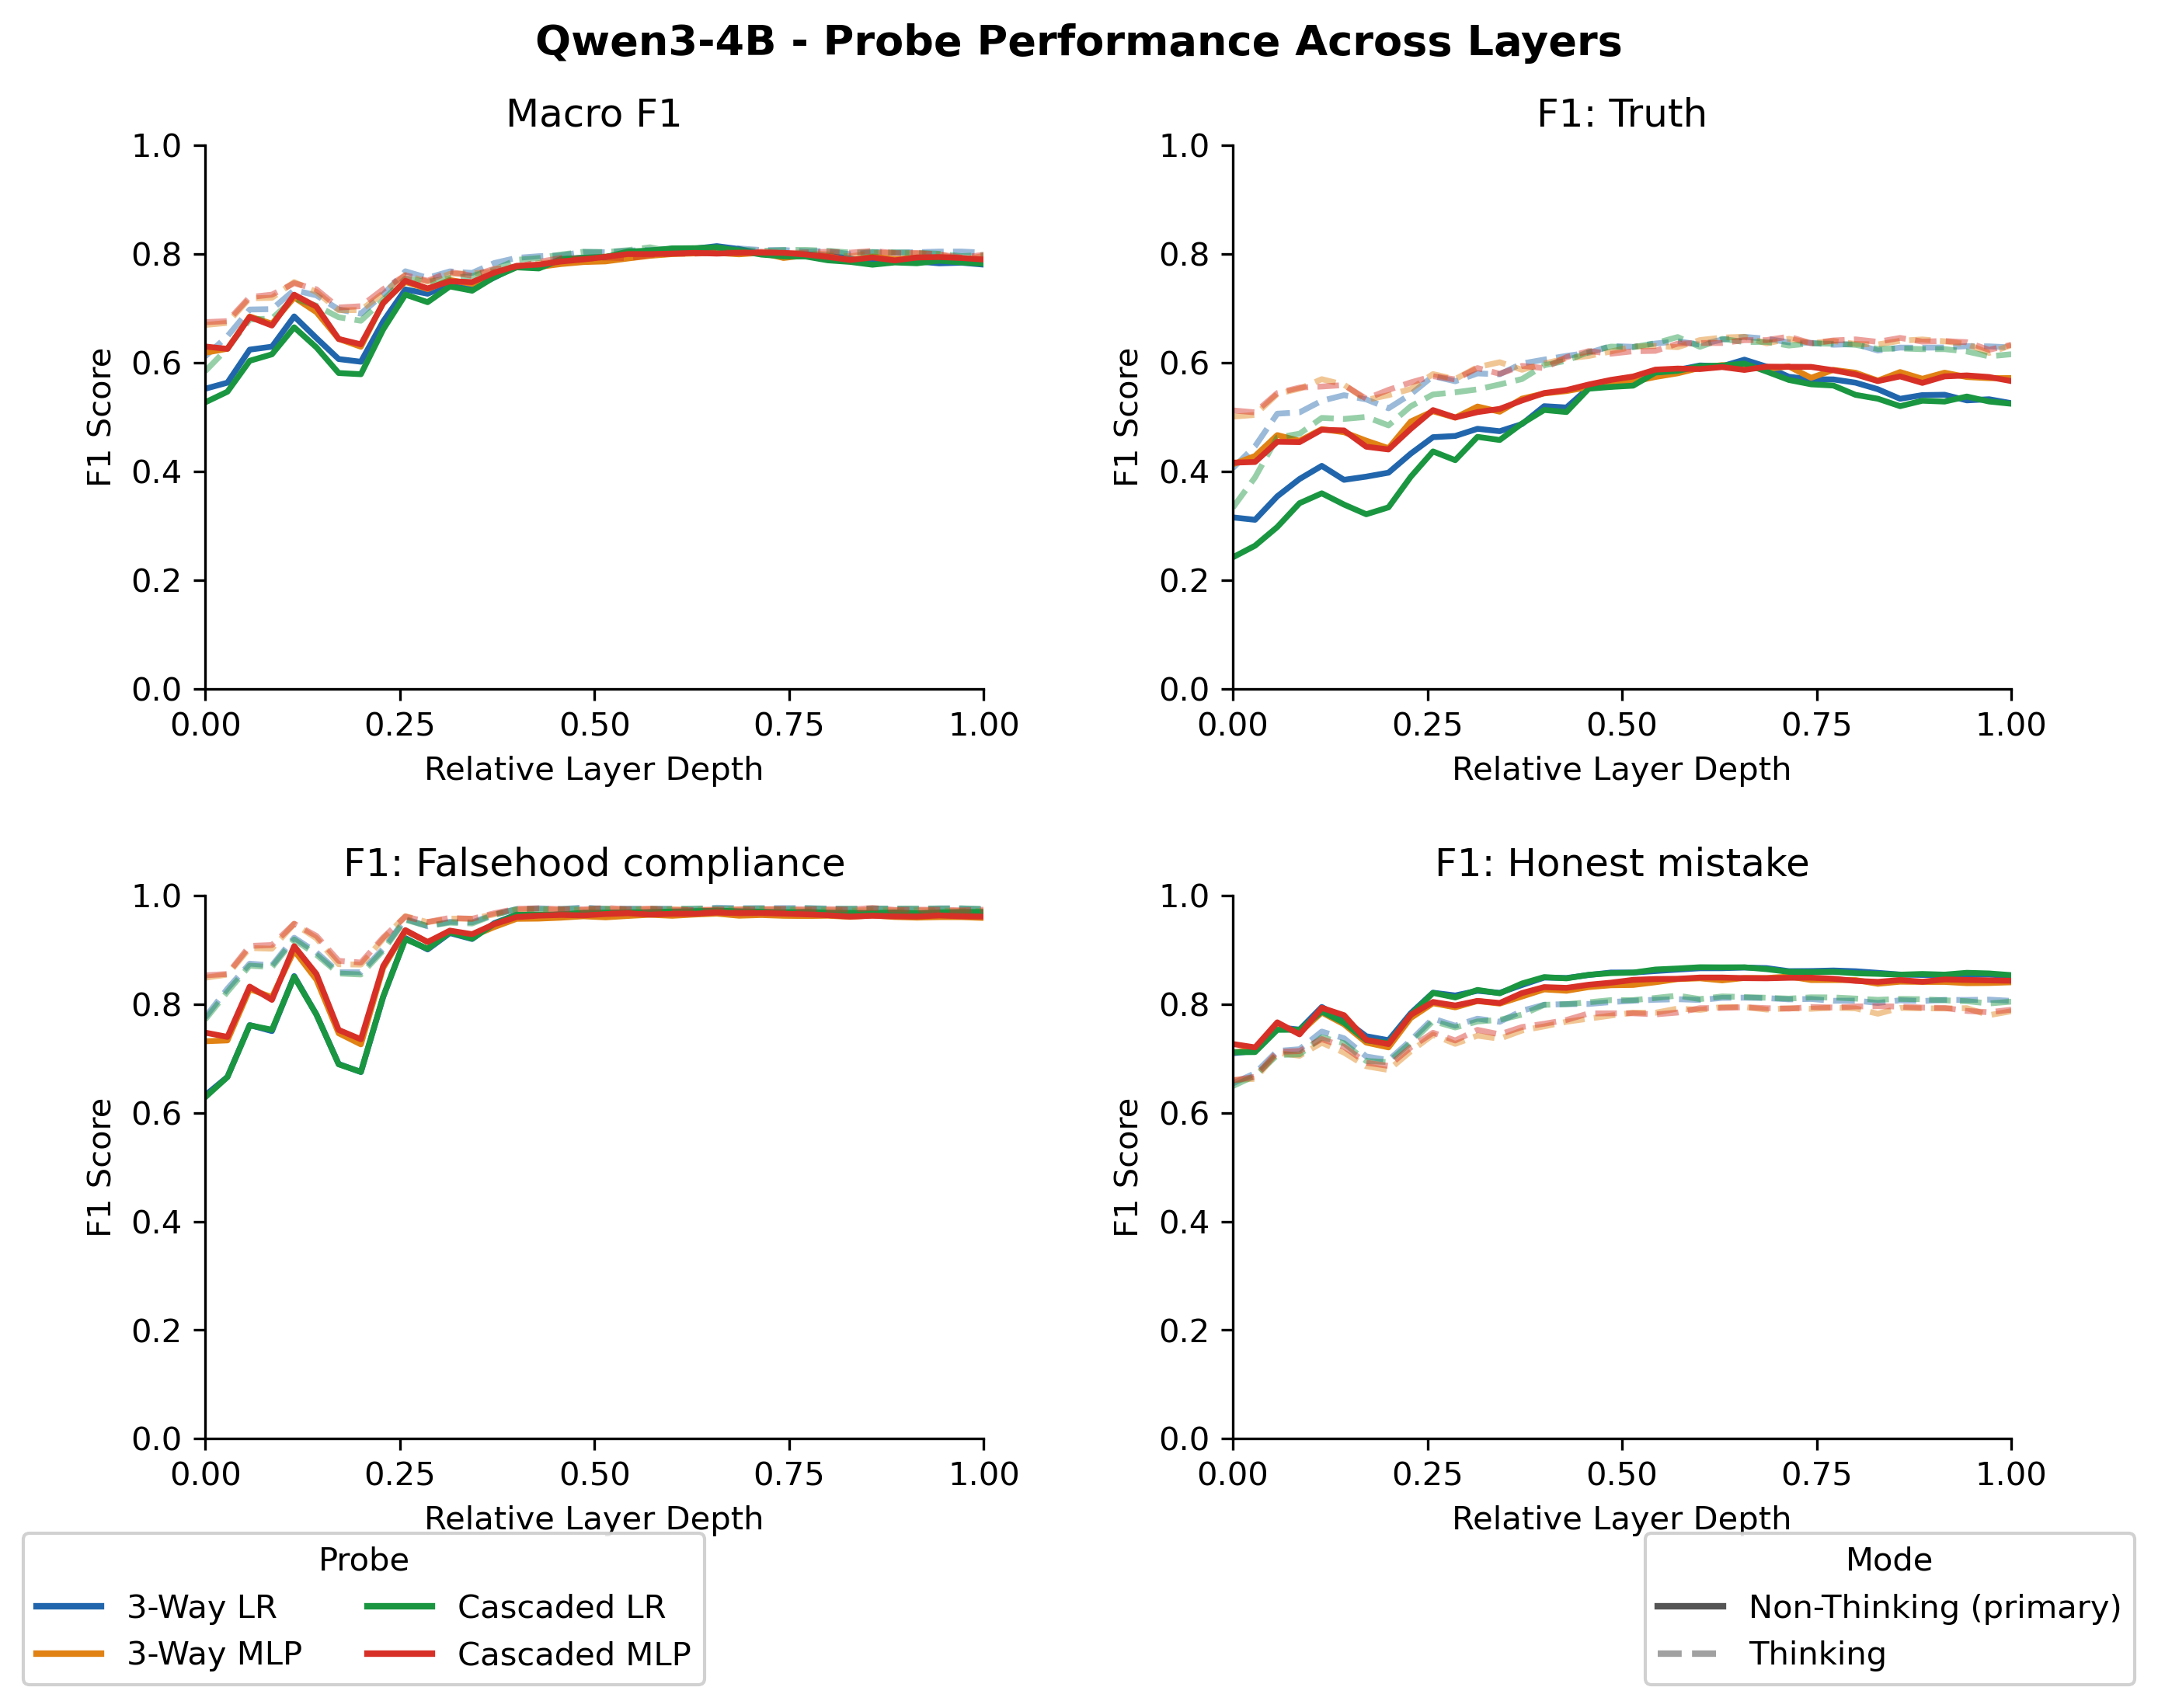

Saved: summary\figures_revision\fig4_gemma4_probe_performance.[pdf|png]


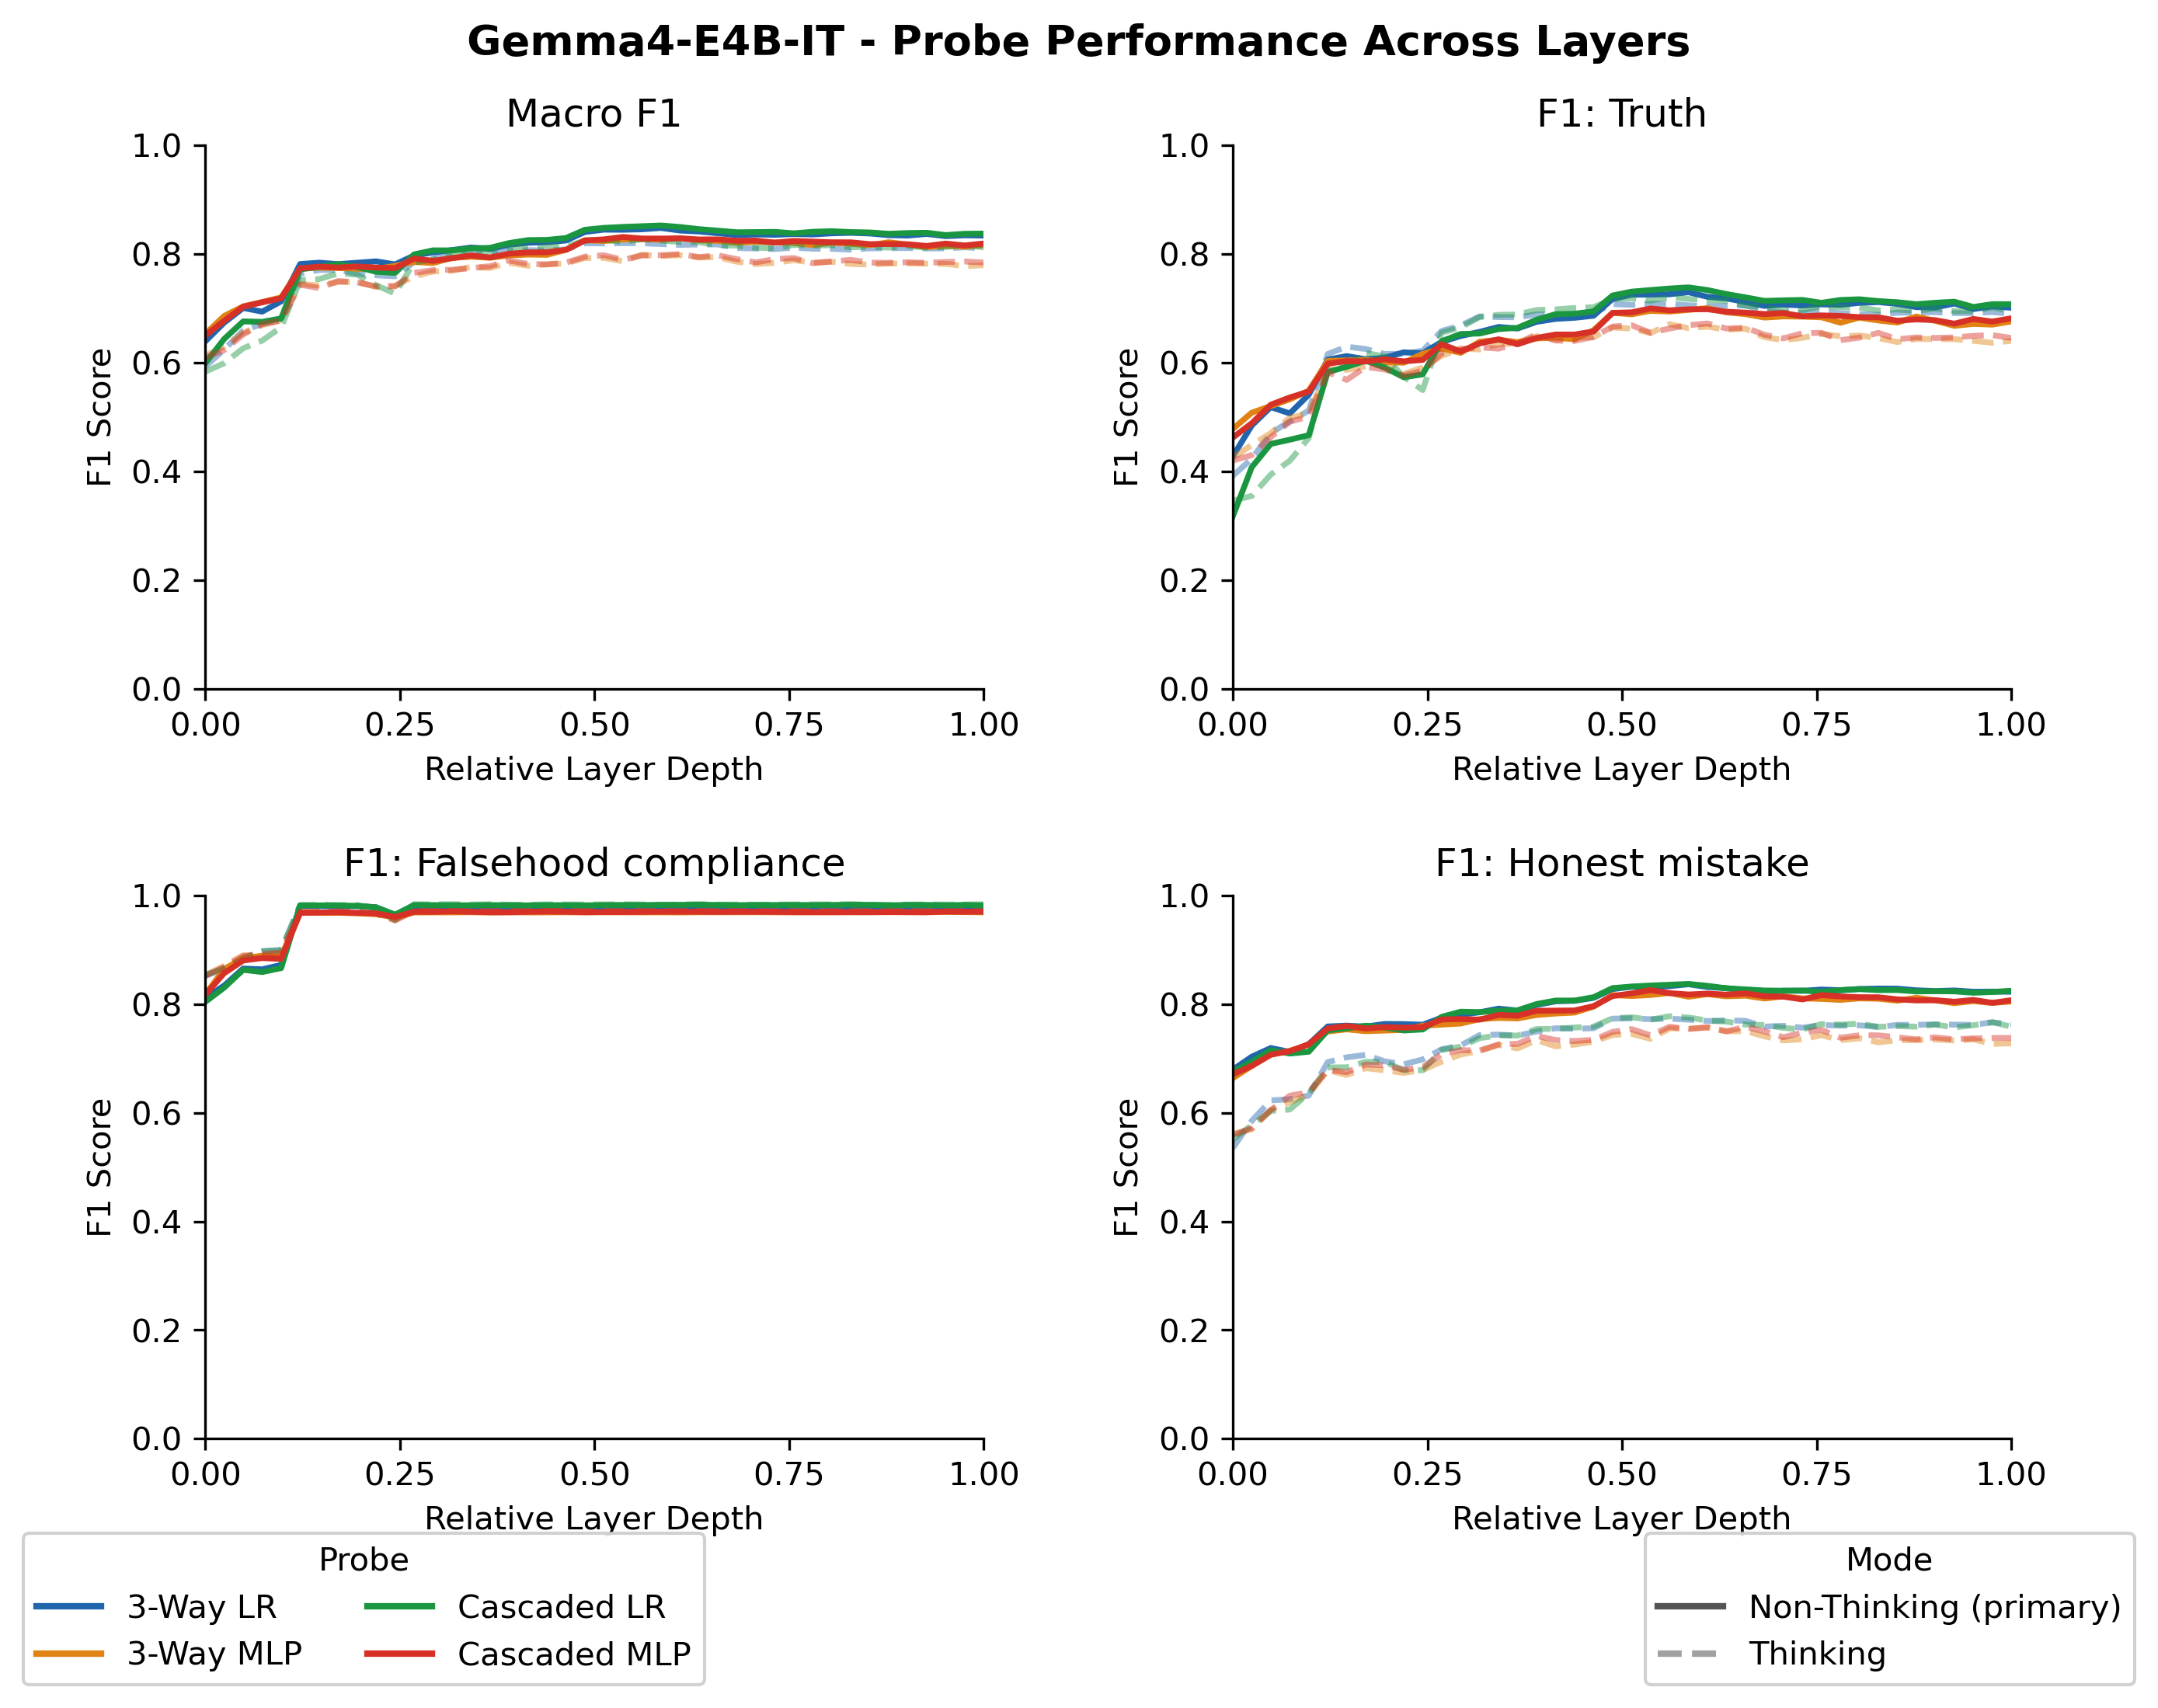

In [5]:
def _load_tm(model_slug, mode, probe_key):
    df = pd.read_csv(SUMMARY_DIR / f"{model_slug}_{mode}_mode_{probe_key}.csv")
    df["rel_layer"] = df["layer"] / (len(df) - 1)
    return df

def plot_thinking_comparison(model_slug, title, save_name):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
    fig.subplots_adjust(hspace=0.38, wspace=0.32, bottom=0.16, top=0.90)
    for ax, (col, panel_title) in zip(axes.flat, METRICS):
        for probe_key, _, color in PROBES:
            df_nt = _load_tm(model_slug, "non_thinking", probe_key)
            df_t  = _load_tm(model_slug, "thinking",     probe_key)
            ax.plot(df_nt["rel_layer"], df_nt[col], color=color, ls="-",  alpha=1.0,  lw=1.8)
            ax.plot(df_t["rel_layer"],  df_t[col],  color=color, ls="--", alpha=0.45, lw=1.8)
        ax.set_title(panel_title, fontsize=12)
        ax.set_xlabel("Relative Layer Depth", fontsize=10)
        ax.set_ylabel("F1 Score", fontsize=10)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=0.97)
    probe_handles = [Line2D([0], [0], color=c, lw=2, ls="-", label=lbl) for _, lbl, c in PROBES]
    style_handles = [
        Line2D([0], [0], color="#555555", lw=2, ls="-",  label="Non-Thinking (primary)"),
        Line2D([0], [0], color="#555555", lw=2, ls="--", alpha=0.55, label="Thinking"),
    ]
    fig.legend(handles=probe_handles, title="Probe", title_fontsize=10,
               ncols=2, loc="lower left", bbox_to_anchor=(0.04, 0.01), framealpha=0.9)
    fig.legend(handles=style_handles, title="Mode", title_fontsize=10,
               ncols=1, loc="lower right", bbox_to_anchor=(0.96, 0.01), framealpha=0.9)
    export(fig, save_name)

plot_thinking_comparison("qwen3", "Qwen3-4B - Probe Performance Across Layers",
                         "fig3_qwen3_probe_performance")
plot_thinking_comparison("gemma4", "Gemma4-E4B-IT - Probe Performance Across Layers",
                         "fig4_gemma4_probe_performance")

## Figures 6 & 7 (appendix) — cross-model comparisons (within / across family)

Saved: summary\figures_revision\fig5_qwen25_vs_qwen3nt.[pdf|png]


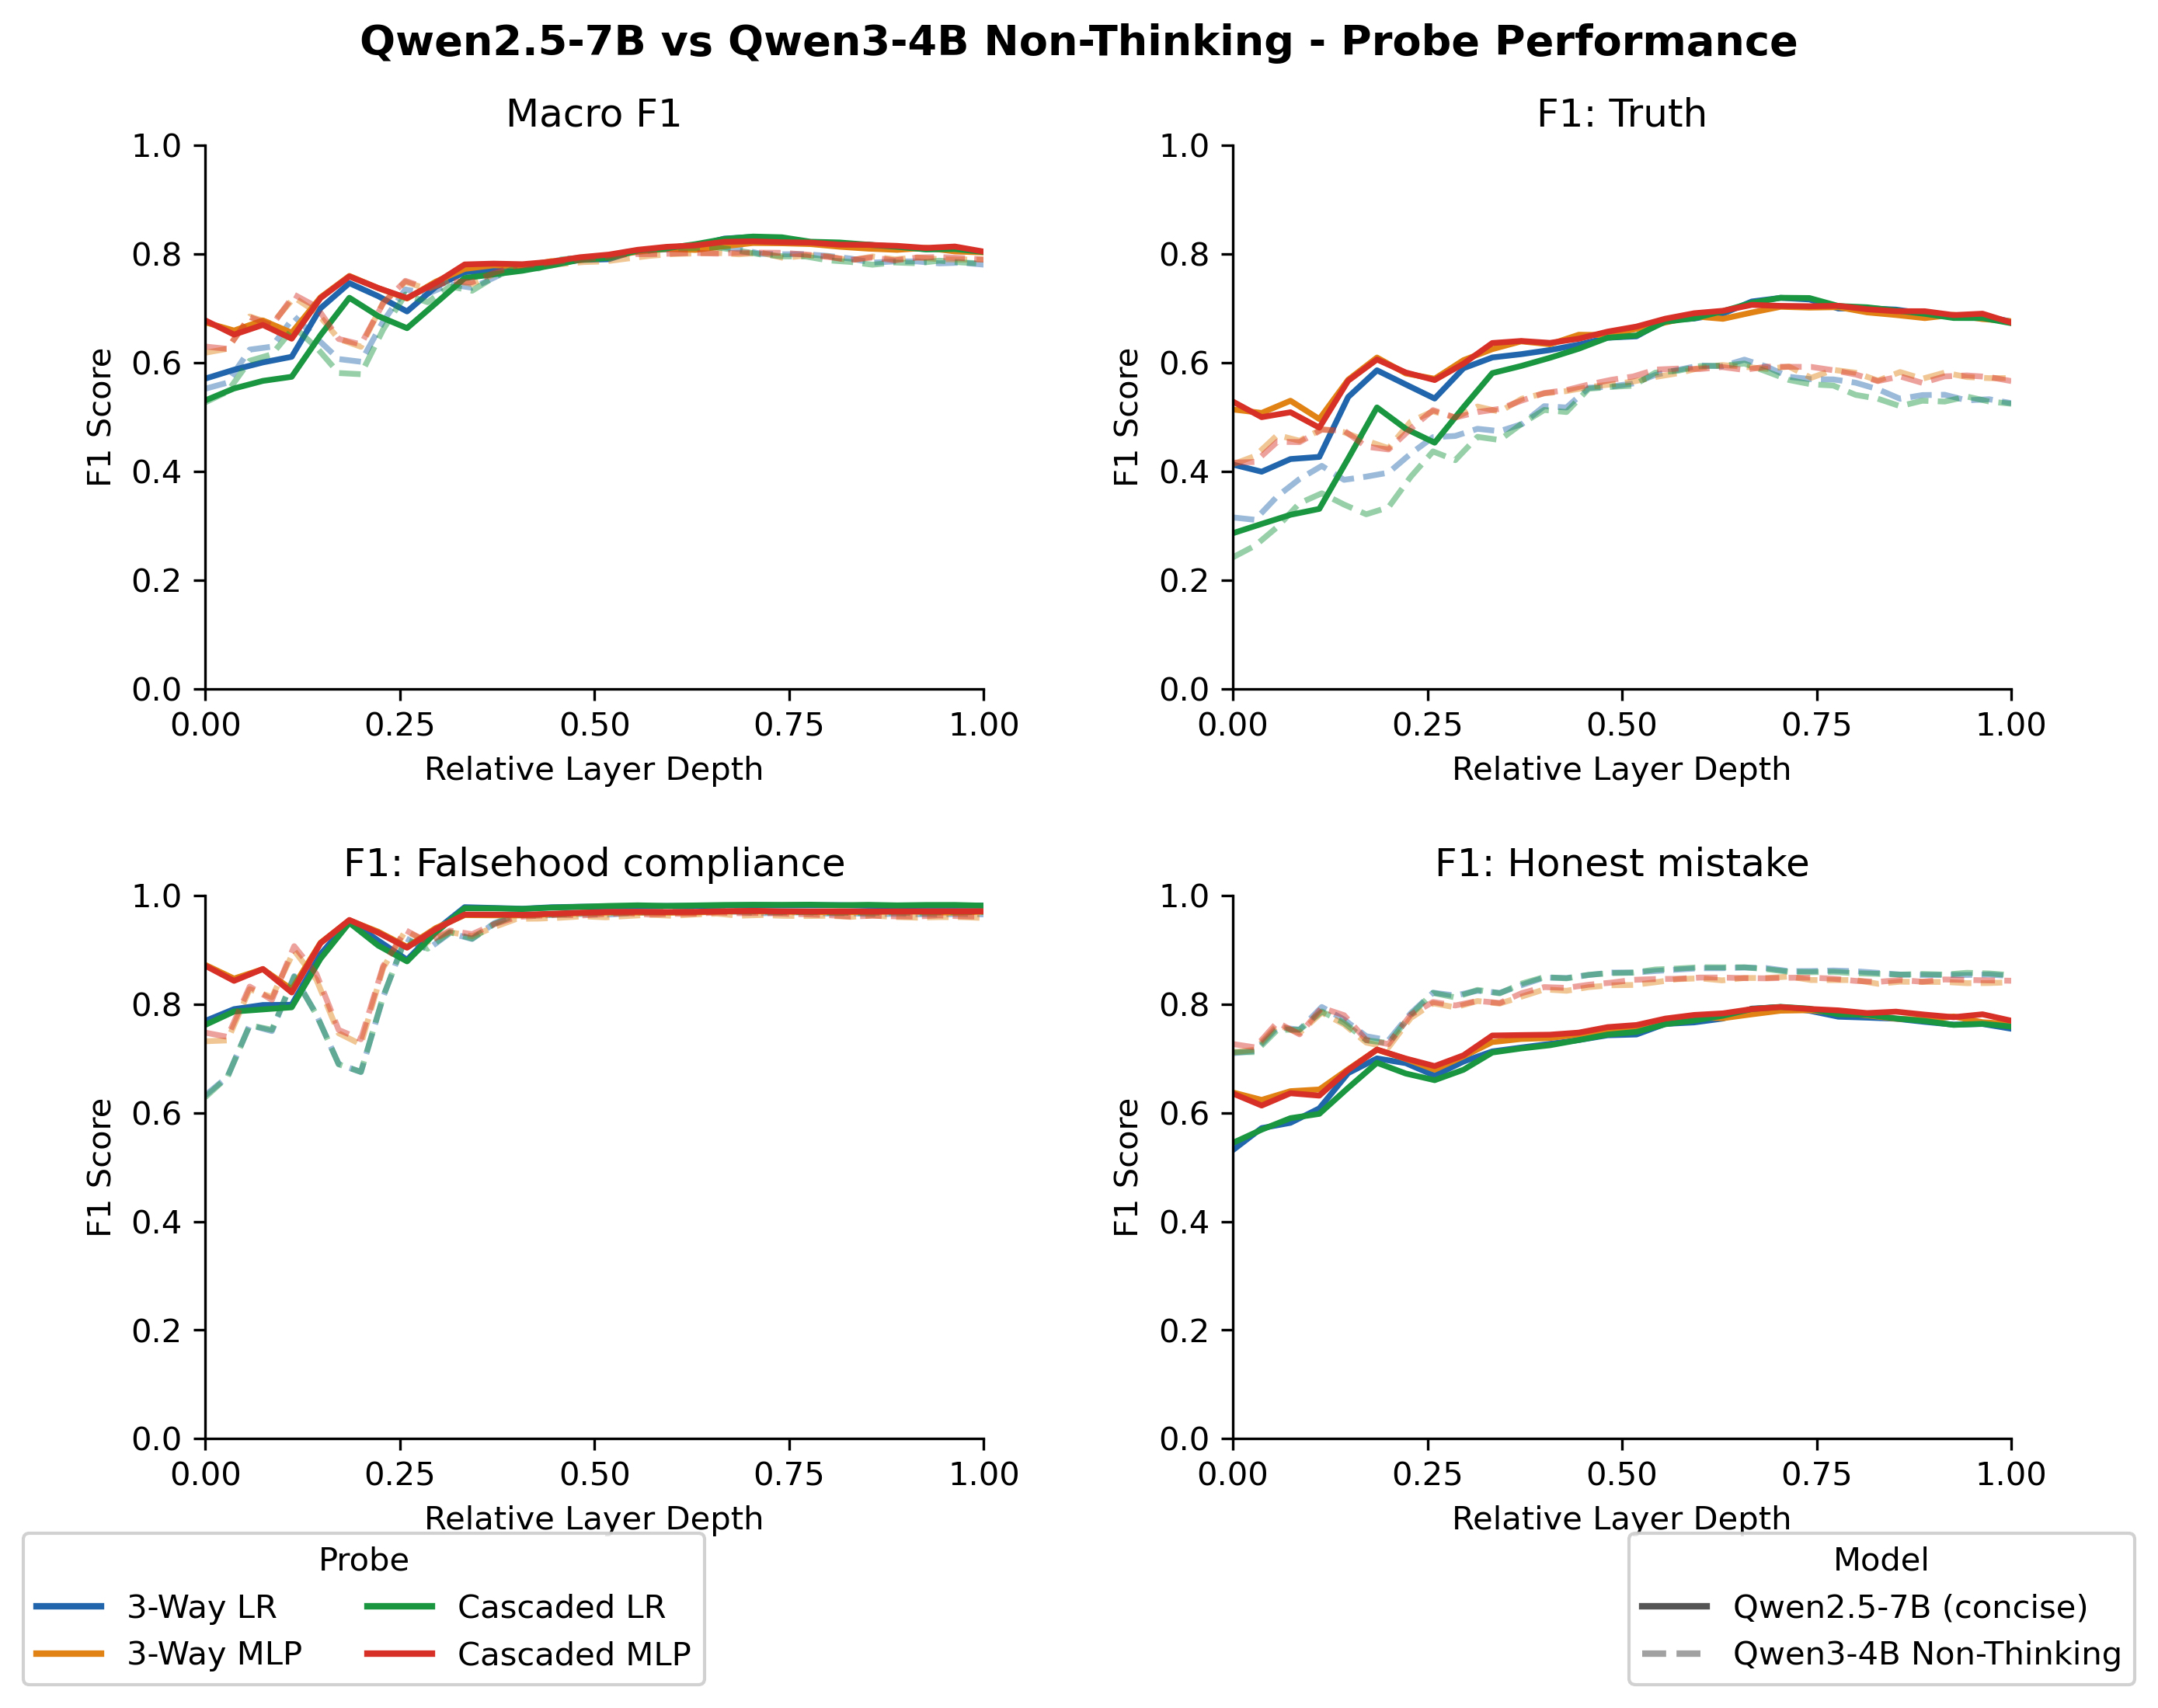

Saved: summary\figures_revision\fig6_qwen25_vs_gemma4nt.[pdf|png]


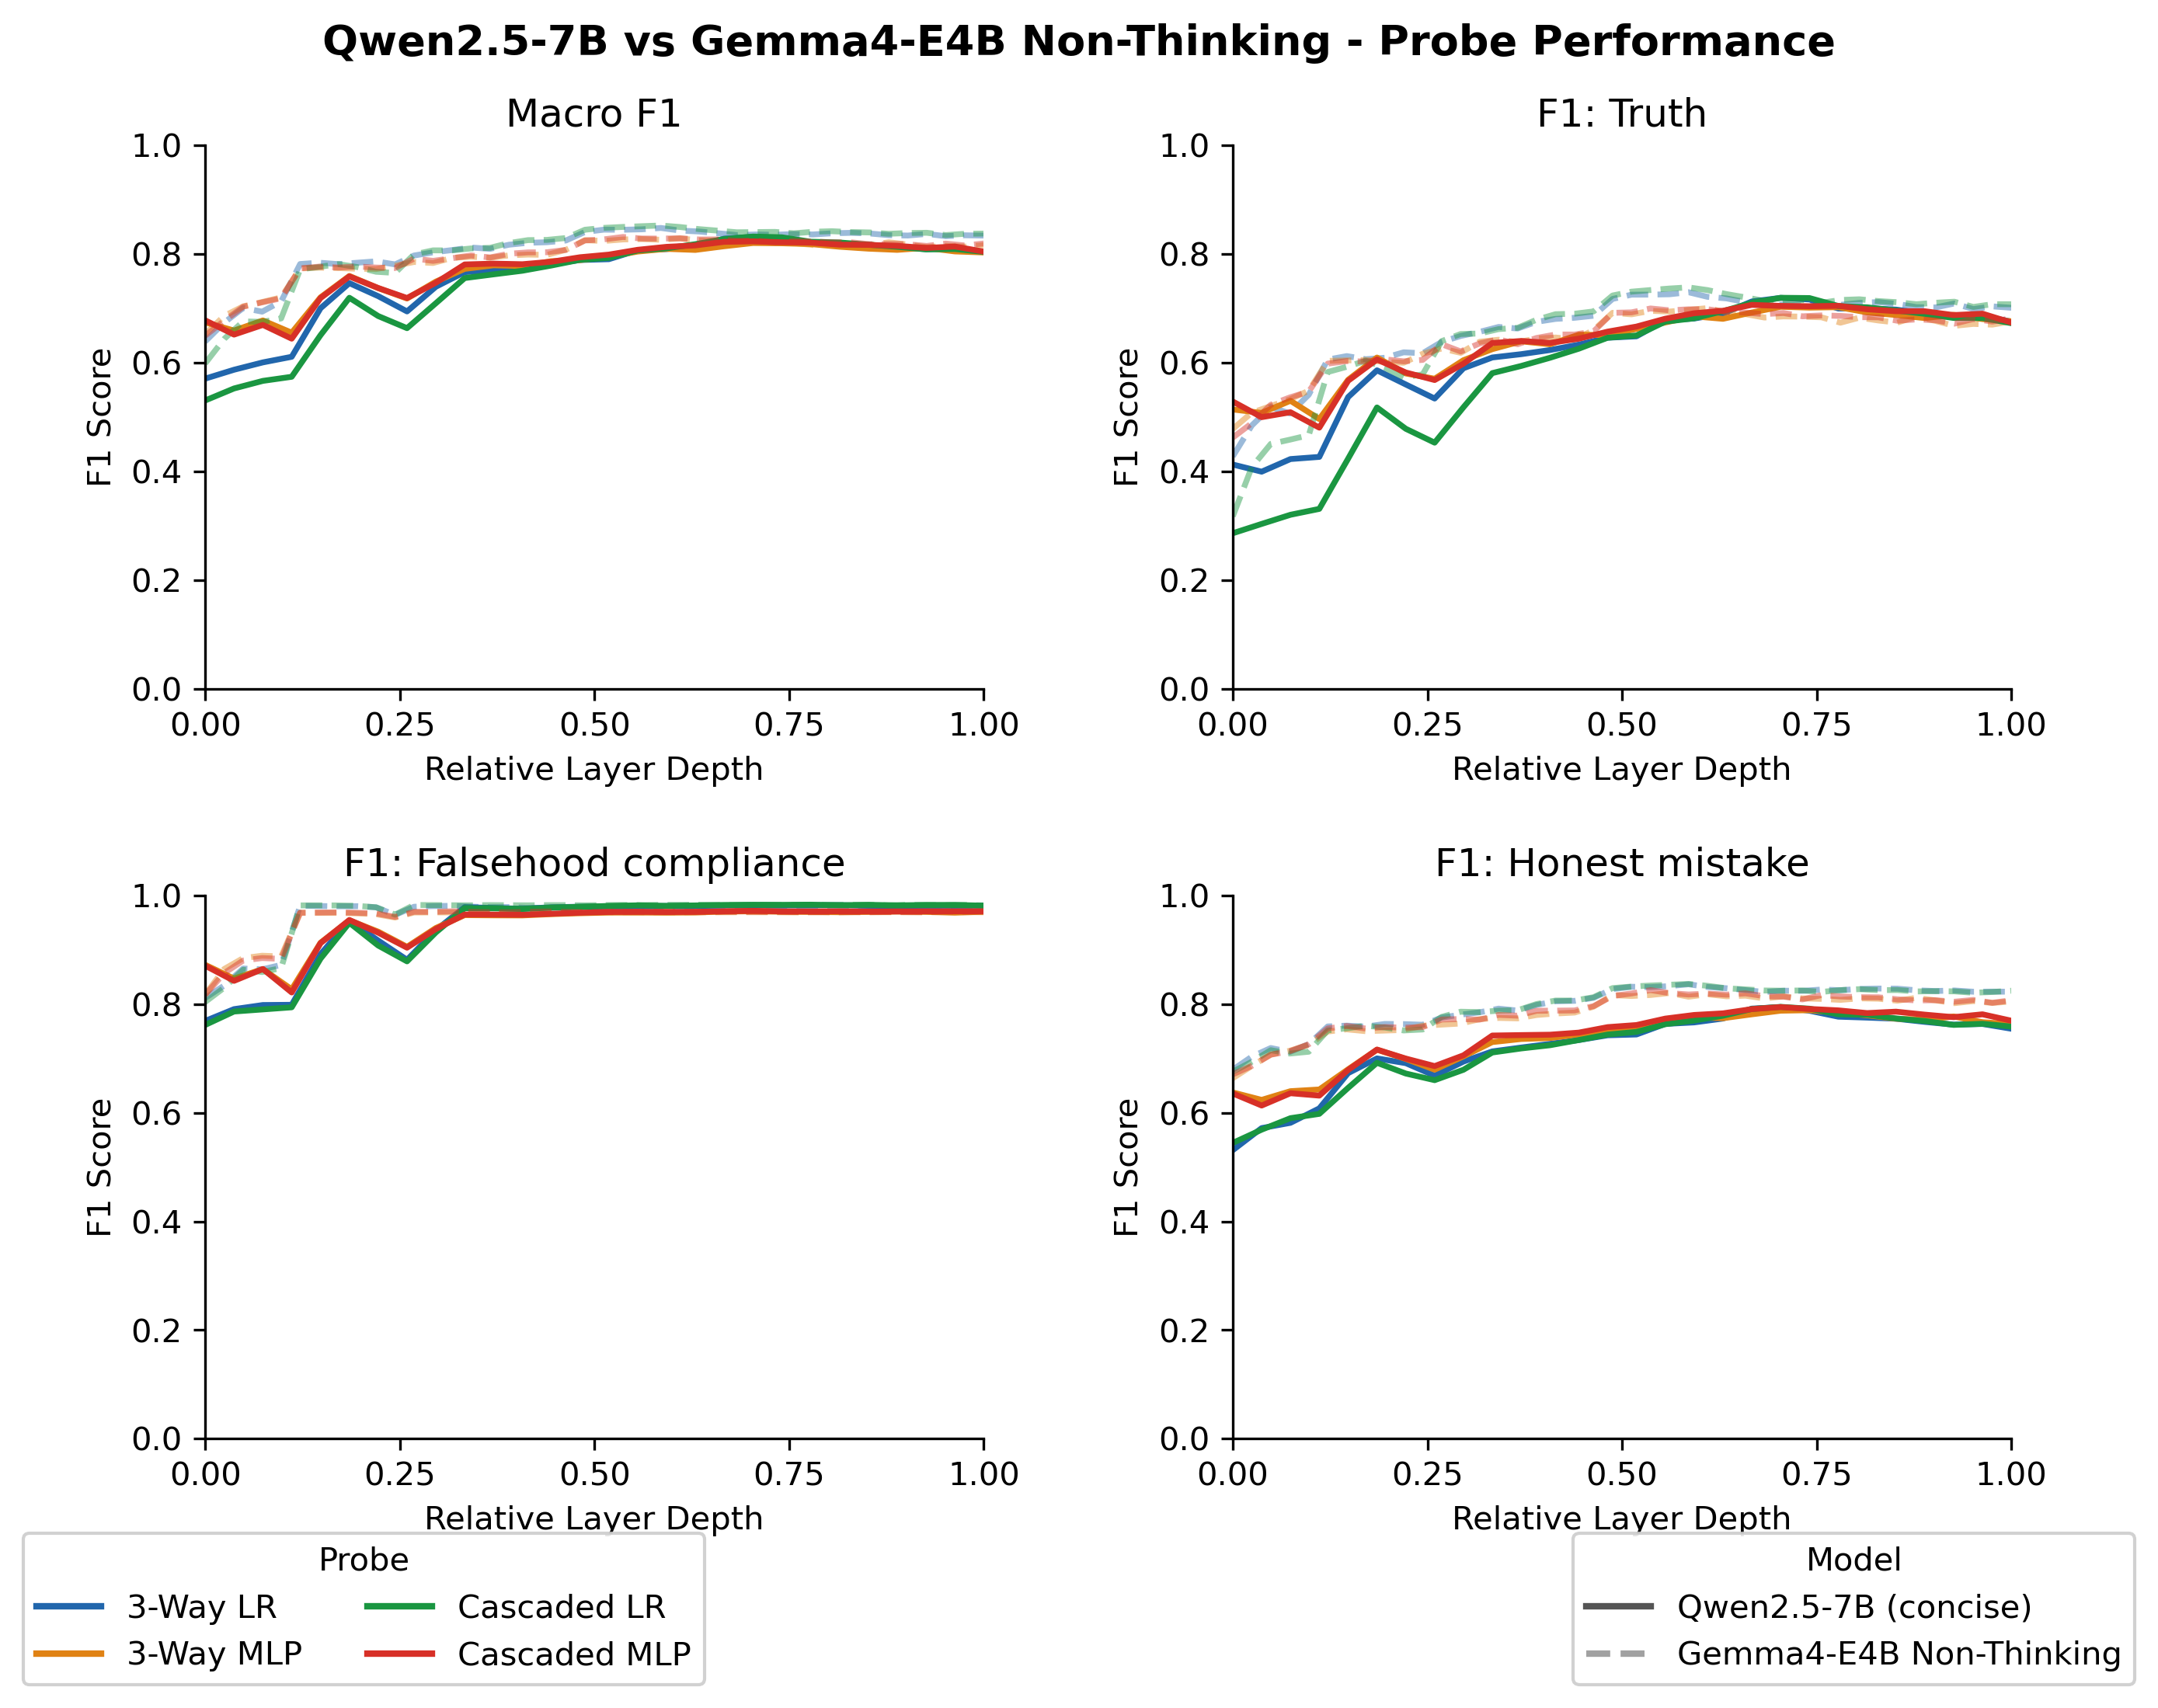

In [6]:
def plot_model_comparison(tmpl_a, label_a, tmpl_b, label_b, title, save_name):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
    fig.subplots_adjust(hspace=0.38, wspace=0.32, bottom=0.16, top=0.90)
    for ax, (col, panel_title) in zip(axes.flat, METRICS):
        for probe_key, _, color in PROBES:
            df_a = pd.read_csv(SUMMARY_DIR / f"{tmpl_a.format(probe=probe_key)}.csv")
            df_b = pd.read_csv(SUMMARY_DIR / f"{tmpl_b.format(probe=probe_key)}.csv")
            df_a["rel_layer"] = df_a["layer"] / (len(df_a) - 1)
            df_b["rel_layer"] = df_b["layer"] / (len(df_b) - 1)
            ax.plot(df_a["rel_layer"], df_a[col], color=color, ls="-",  alpha=1.0,  lw=1.8)
            ax.plot(df_b["rel_layer"], df_b[col], color=color, ls="--", alpha=0.45, lw=1.8)
        ax.set_title(panel_title, fontsize=12)
        ax.set_xlabel("Relative Layer Depth", fontsize=10)
        ax.set_ylabel("F1 Score", fontsize=10)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=0.97)
    probe_handles = [Line2D([0], [0], color=c, lw=2, ls="-", label=lbl) for _, lbl, c in PROBES]
    model_handles = [
        Line2D([0], [0], color="#555555", lw=2, ls="-",  label=label_a),
        Line2D([0], [0], color="#555555", lw=2, ls="--", alpha=0.55, label=label_b),
    ]
    fig.legend(handles=probe_handles, title="Probe", title_fontsize=10,
               ncols=2, loc="lower left", bbox_to_anchor=(0.04, 0.01), framealpha=0.9)
    fig.legend(handles=model_handles, title="Model", title_fontsize=10,
               ncols=1, loc="lower right", bbox_to_anchor=(0.96, 0.01), framealpha=0.9)
    export(fig, save_name)

plot_model_comparison("qwen2.5_{probe}_concise",         "Qwen2.5-7B (concise)",
                      "qwen3_non_thinking_mode_{probe}",  "Qwen3-4B Non-Thinking",
                      "Qwen2.5-7B vs Qwen3-4B Non-Thinking - Probe Performance",
                      "fig5_qwen25_vs_qwen3nt")
plot_model_comparison("qwen2.5_{probe}_concise",          "Qwen2.5-7B (concise)",
                      "gemma4_non_thinking_mode_{probe}",  "Gemma4-E4B Non-Thinking",
                      "Qwen2.5-7B vs Gemma4-E4B Non-Thinking - Probe Performance",
                      "fig6_qwen25_vs_gemma4nt")

## Figures 8 & 9 (appendix) — cascaded all-configs six-panel decomposition

Bottom-right panel relabeled **Stage 2: Falsehood-Compliance F1** (Stage 2 separates
Honest mistake vs. Falsehood compliance).

Saved: summary\figures_revision\cascaded_lr_all_configs.[pdf|png]


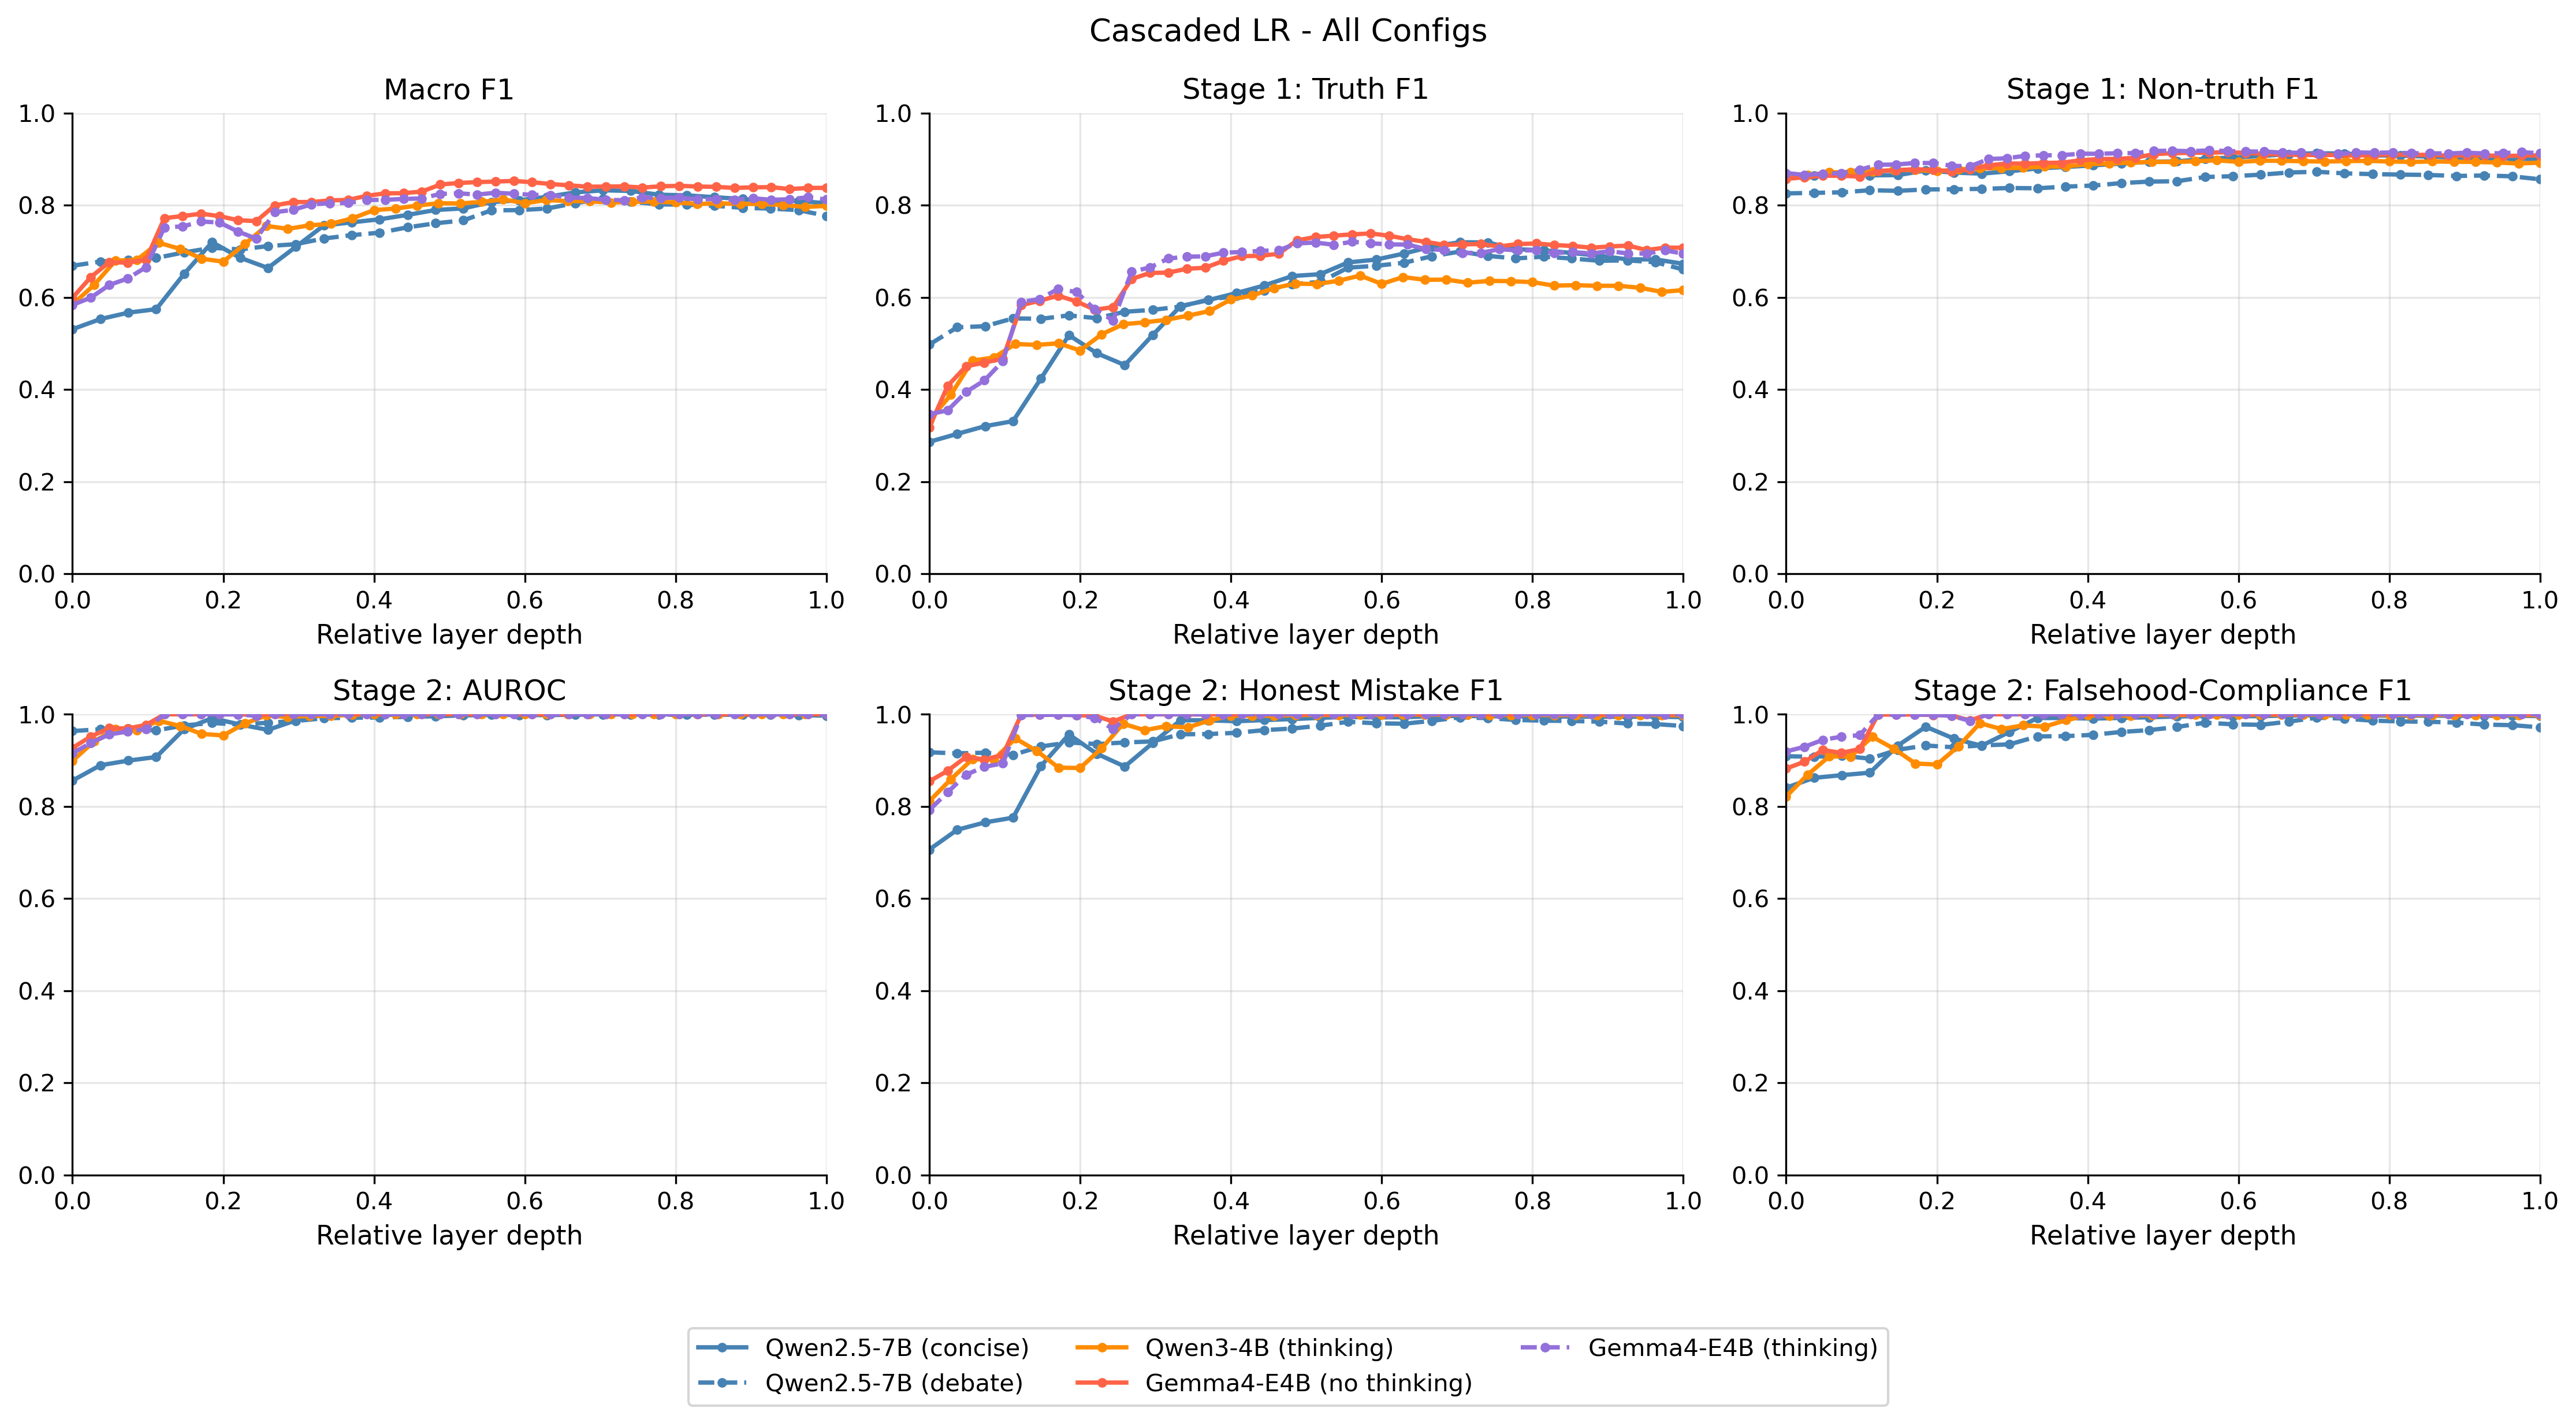

Saved: summary\figures_revision\cascaded_mlp_all_configs.[pdf|png]


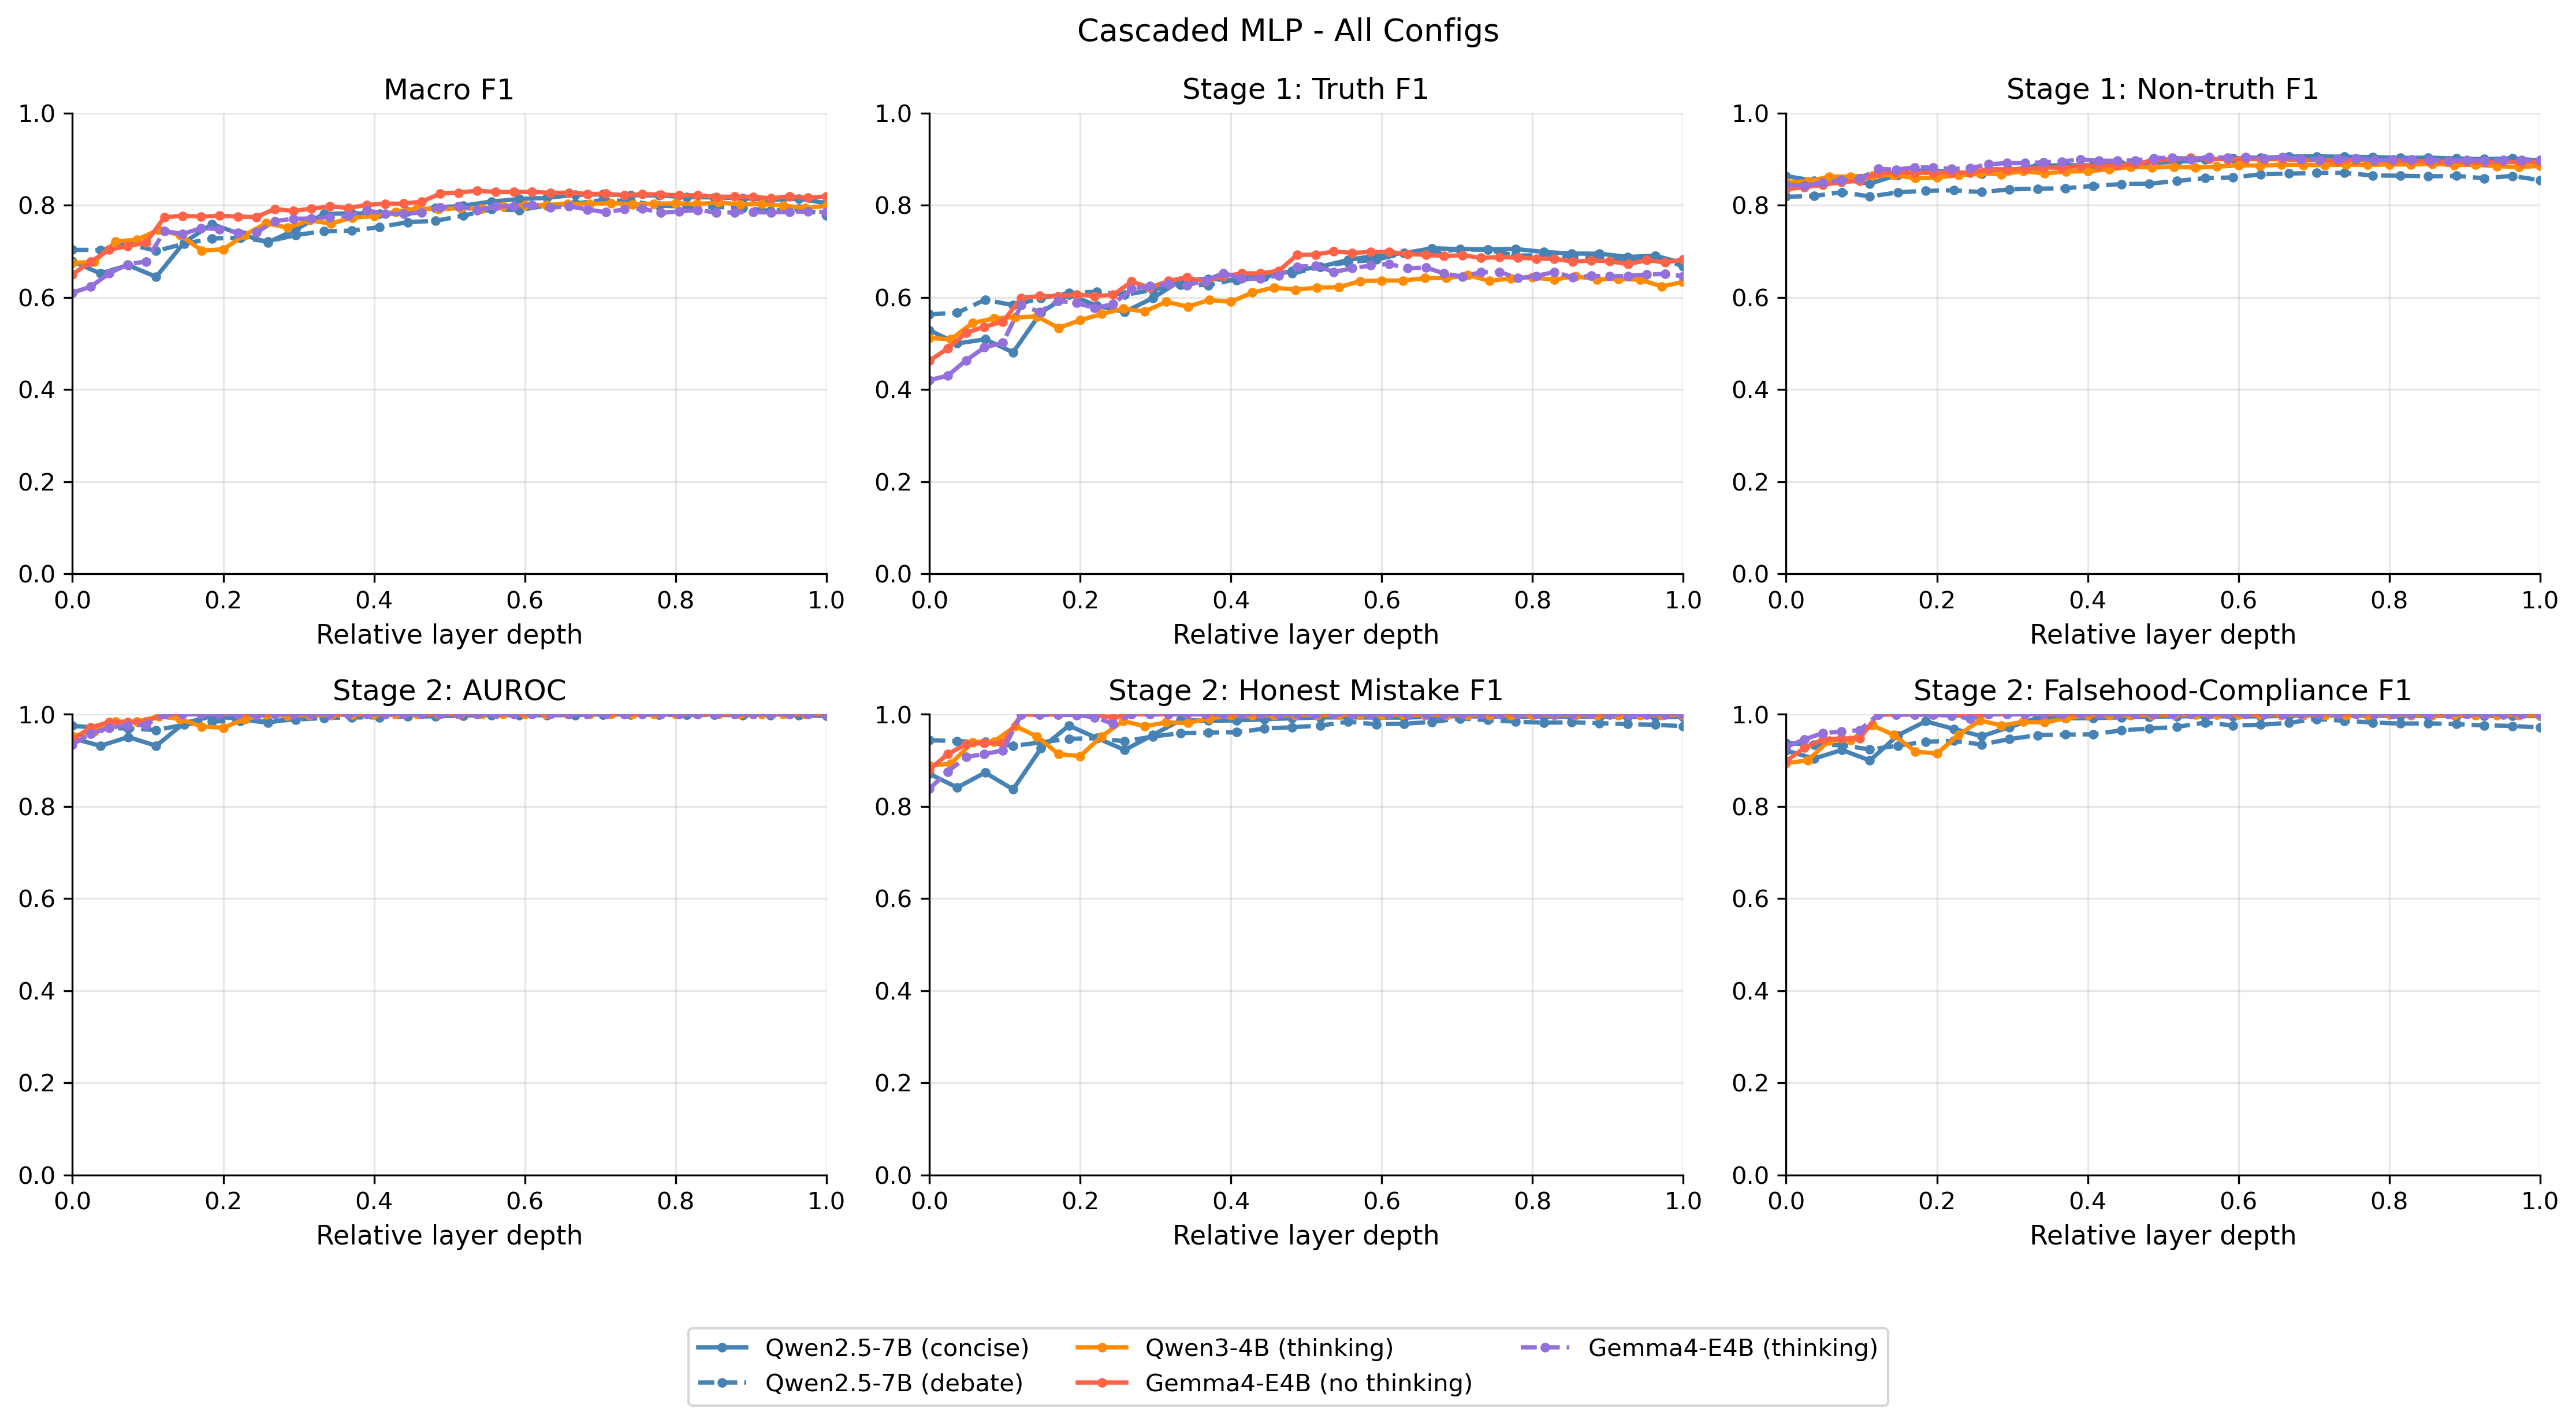

In [7]:
CASCADED_METRICS = [
    ("f1_macro",                 "Macro F1"),
    ("stage1_f1_truth",          "Stage 1: Truth F1"),
    ("stage1_f1_non_truth",      "Stage 1: Non-truth F1"),
    ("stage2_auroc",             "Stage 2: AUROC"),
    ("stage2_f1_honest_mistake", "Stage 2: Honest Mistake F1"),
    ("stage2_f1_deception",      "Stage 2: Falsehood-Compliance F1"),
]
CASC_CONFIGS = [
    ("qwen2.5_cascaded_{c}_concise",          "Qwen2.5-7B (concise)",     "steelblue",    "-"),
    ("qwen2.5_cascaded_{c}_debate",           "Qwen2.5-7B (debate)",      "steelblue",    "--"),
    ("qwen3_thinking_mode_cascaded_{c}",      "Qwen3-4B (thinking)",      "darkorange",   "-"),
    ("gemma4_non_thinking_mode_cascaded_{c}", "Gemma4-E4B (no thinking)", "tomato",       "-"),
    ("gemma4_thinking_mode_cascaded_{c}",     "Gemma4-E4B (thinking)",    "mediumpurple", "--"),
]

def plot_cascaded_all_configs(classifier, save_name):
    label = "LR" if classifier == "lr" else "MLP"
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, (col, title) in zip(axes.flat, CASCADED_METRICS):
        for tmpl, clabel, color, ls in CASC_CONFIGS:
            df = pd.read_csv(SUMMARY_DIR / f"{tmpl.format(c=classifier)}.csv")
            df["rel_layer"] = df["layer"] / (len(df) - 1)
            valid = df[["rel_layer", col]].dropna()
            if valid.empty:
                continue
            ax.plot(valid["rel_layer"], valid[col], label=clabel, color=color,
                    linestyle=ls, marker="o", markersize=3)
        ax.set_title(title)
        ax.set_xlabel("Relative layer depth")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(f"Cascaded {label} - All Configs", fontsize=13)
    fig.tight_layout(rect=[0, 0.07, 1, 1])
    export(fig, save_name)

plot_cascaded_all_configs("lr",  "cascaded_lr_all_configs")
plot_cascaded_all_configs("mlp", "cascaded_mlp_all_configs")